# IntraSight-ESI: Finding Hidden Risk Within Triage Categories

**A system for identifying high-risk patients hiding within the same triage category**

---

*This notebook tells the complete story — from clinical motivation through synthetic-data failure,
to robust validation on five years of real emergency visits and an independent temporal holdout.
All intermediate work lives in NB01–NB04; this notebook synthesizes and narrates.*

---


---
## Data and Artifact Disclosure

### How to reproduce this notebook on Kaggle

This notebook loads **pre-computed artifacts** (JSON metrics, PNG figures, CSV tables)
generated by the four intermediate notebooks (NB00–NB04) in this project. It recalculates
nothing. To run on Kaggle, attach the companion dataset as described below.

### Required Kaggle Dataset

Upload the `reports/` folder from this project as a Kaggle Dataset named
**`triagegeist-artifacts`**. The dataset should contain:

```
triagegeist-artifacts/
  reports/
    02_model_validation/
      02_metrics_summary.json          ← LOYO AUC, CI per ESI and feature set
      02_permutation_test.json         ← Intra-ESI permutation test results
      02_roc_curves.png                ← ROC curve figure
      02_pr_curves.png                 ← Precision-recall curve figure
      02_shap_beeswarm_esi4.png        ← SHAP beeswarm for ESI 4
      02_alert_examples_esi4.csv       ← Annotated alert examples
      02_alert_examples_enriched.csv   ← Alert examples with RFV1/RFV2 codes for chief-complaint detail
      02_oof_predictions_esi3.csv      ← Out-of-fold predictions ESI 3
      02_oof_predictions_esi4.csv      ← Out-of-fold predictions ESI 4
      02_oof_predictions_esi5.csv      ← Out-of-fold predictions ESI 5
    03_alert_policy/
      03_final_policy.json             ← Alert thresholds, PPV, enrichment, recall
      03_model_vs_baselines.csv        ← Model vs clinical rules comparison
    04_validation_subgroups_fairness/
      04_calibration_before_after.json ← Brier skill before/after calibration
      04_holdout_2015_results.json     ← 2015 independent holdout metrics
      04_subgroup_age65.csv            ← Age subgroup enrichment results
      04_fairness_analysis.csv         ← Fairness audit by demographic group
      04_reliability_diagrams.png      ← Reliability diagram figure
      04_subgroup_age65_plot.png       ← Age subgroup comparison figure
      04_fairness_by_group.png         ← Fairness figure
      04_holdout_vs_cv_plot.png        ← Holdout vs CV comparison figure
    02b_logistic_baseline/
      02b_logreg_vs_lgbm.csv          ← Full comparison table (LogReg vs LightGBM)
      02b_logreg_vs_lgbm.json         ← Same as JSON for loading
      02b_logreg_vs_lgbm.png          ← Enrichment comparison figure
      02b_logreg_vs_lgbm_auc.png      ← AUC comparison figure
```

### Data source and licensing

**NHAMCS (National Hospital Ambulatory Medical Care Survey)**
- Provider: CDC / National Center for Health Statistics (NCHS)
- Coverage: Emergency department visits, US nationally representative sample
- Years used: 2016, 2017, 2018, 2019, 2022 (training) + 2015 (independent holdout)
- Access: Public domain — freely available at https://www.cdc.gov/nchs/ahcd/
- Citation: *National Center for Health Statistics. National Hospital Ambulatory Medical
  Care Survey. Hyattsville, MD: CDC/NCHS.*

All intermediate code (parsing, feature engineering, model training, artifact generation)
is available in NB01–NB04 of the same project. Nothing in this notebook was derived
from external datasets or private data.

---


In [1]:
import os
from pathlib import Path

# Fix CWD: VS Code Jupyter may start kernel in notebooks/ instead of project root
try:
    os.chdir(Path(__vsc_ipynb_file__).parent.parent)
except NameError:
    if Path(os.getcwd()).name == 'notebooks':
        os.chdir(Path(os.getcwd()).parent)

# ── Auto-detect Kaggle vs local environment ───────────────────────────────
KAGGLE = os.path.exists('/kaggle/input')

if KAGGLE:
    ARTIFACT_ROOT = Path('/kaggle/input/triagegeist-artifacts')
    OUT_DIR       = Path('/kaggle/working')
    print("Environment: Kaggle")
else:
    ARTIFACT_ROOT = Path('.')
    OUT_DIR       = Path('reports')
    print("Environment: Local")

R02 = ARTIFACT_ROOT / 'reports/02_model_validation'
R03 = ARTIFACT_ROOT / 'reports/03_alert_policy'
R04 = ARTIFACT_ROOT / 'reports/04_validation_subgroups_fairness'

OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"  Artifact root : {ARTIFACT_ROOT}")
print(f"  Output dir    : {OUT_DIR}")


Environment: Local
  Artifact root : .
  Output dir    : reports


In [2]:
# ── Validate required artifacts before loading ────────────────────────────
REQUIRED = {
    'NB02 metrics'         : R02 / '02_metrics_summary.json',
    'NB02 permutation test': R02 / '02_permutation_test.json',
    'NB02 ROC curves'      : R02 / '02_roc_curves.png',
    'NB02 PR curves'       : R02 / '02_pr_curves.png',
    'NB02 SHAP beeswarm'   : R02 / '02_shap_beeswarm_esi4.png',
    'NB02 alert examples'  : R02 / '02_alert_examples_esi4.csv',
    'NB02 alert examples enriched' : R02 / '02_alert_examples_enriched.csv',
    'NB02 OOF ESI3'        : R02 / '02_oof_predictions_esi3.csv',
    'NB02 OOF ESI4'        : R02 / '02_oof_predictions_esi4.csv',
    'NB02 OOF ESI5'        : R02 / '02_oof_predictions_esi5.csv',
    'NB03 policy'          : R03 / '03_final_policy.json',
    'NB03 baselines'       : R03 / '03_model_vs_baselines.csv',
    'NB04 calibration'     : R04 / '04_calibration_before_after.json',
    'NB04 holdout 2015'    : R04 / '04_holdout_2015_results.json',
    'NB04 age subgroup'    : R04 / '04_subgroup_age65.csv',
    'NB04 fairness'        : R04 / '04_fairness_analysis.csv',
    'NB04 reliability plot': R04 / '04_reliability_diagrams.png',
    'NB04 age plot'        : R04 / '04_subgroup_age65_plot.png',
    'NB04 fairness plot'   : R04 / '04_fairness_by_group.png',
    'NB04 holdout plot'    : R04 / '04_holdout_vs_cv_plot.png',
    'NB02b LR comparison'  : ARTIFACT_ROOT / 'reports/02b_logistic_baseline/02b_logreg_vs_lgbm.json',
    'NB02b LR figure'      : ARTIFACT_ROOT / 'reports/02b_logistic_baseline/02b_logreg_vs_lgbm.png',
    'NB02b LR AUC figure'  : ARTIFACT_ROOT / 'reports/02b_logistic_baseline/02b_logreg_vs_lgbm_auc.png',
}

missing = []
for label, path in REQUIRED.items():
    if not path.exists():
        missing.append(f"  MISSING: {label}\n    Expected: {path}")

if missing:
    msg = "\n".join(missing)
    raise FileNotFoundError(
        f"\n{len(missing)} required artifact(s) not found.\n{msg}\n\n"
        "If running on Kaggle: attach the 'triagegeist-artifacts' dataset.\n"
        "If running locally: ensure NB01-NB04 have been executed first."
    )

print(f"All {len(REQUIRED)} required artifacts found.")


All 23 required artifacts found.


In [3]:
import json
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.gridspec as gridspec

warnings.filterwarnings('ignore')
plt.rcParams.update({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})

# R02, R03, R04, OUT_DIR are defined in the path setup cell above
R02b = ARTIFACT_ROOT / 'reports/02b_logistic_baseline'
with open(R02 / '02_metrics_summary.json')          as f: metrics     = json.load(f)
with open(R02 / '02_permutation_test.json')         as f: perm        = json.load(f)
with open(R03 / '03_final_policy.json')             as f: policy      = json.load(f)
with open(R04 / '04_calibration_before_after.json') as f: calibration = json.load(f)
with open(R04 / '04_holdout_2015_results.json')     as f: holdout     = json.load(f)

df_baselines = pd.read_csv(R03 / '03_model_vs_baselines.csv')
df_age65     = pd.read_csv(R04 / '04_subgroup_age65.csv')
df_fairness  = pd.read_csv(R04 / '04_fairness_analysis.csv')
df_alerts    = pd.read_csv(R02 / '02_alert_examples_esi4.csv')
df_oof3      = pd.read_csv(R02 / '02_oof_predictions_esi3.csv')
df_oof4      = pd.read_csv(R02 / '02_oof_predictions_esi4.csv')
df_oof5      = pd.read_csv(R02 / '02_oof_predictions_esi5.csv')
df_alerts_enriched = pd.read_csv(R02 / '02_alert_examples_enriched.csv')

print("All artifacts loaded.")
print(f"  Training OOF: ESI3={len(df_oof3):,}  ESI4={len(df_oof4):,}  ESI5={len(df_oof5):,} patients")


All artifacts loaded.
  Training OOF: ESI3=31,460  ESI4=20,182  ESI5=3,102 patients


---
## Section 1 — The Clinical Problem

### Two patients, same score, different fates

As an emergency physician, I've seen it happen more than once.

Two patients arrive within minutes of each other, both triaged as **ESI 4** — lower-acuity, expected to wait.
They sit in the same waiting room. Two hours later, one goes home with a prescription.
The other is admitted to the ICU.

ESI captured each patient's immediate acuity, as it is designed to do, while the model
estimates downstream serious-outcome risk within the same ESI category. But ESI was never
designed to predict where a patient ends up at the end of their visit. That gap — between
triage category and actual clinical destination — is the problem IntraSight-ESI tries to address.

### What the Emergency Severity Index does well (and what it doesn't)

The ESI (1–5 scale, 1 = most urgent) is one of the most validated triage tools in emergency medicine.
It reliably separates patients who need immediate, life-saving intervention or rapid high-risk
evaluation (ESI 1-2) from those whose downstream clinical course is less immediately apparent (ESI 3-5).
Within ESI 3-5, however, patients with very different downstream clinical courses share the same waiting room:

| ESI Category | Typical presentation | Serious outcome rate — hospitalization, transfer, or ED death (NHAMCS 2016-2022) |
|---|---|---|
| ESI 3 | Moderate acuity, 2+ resources expected | **13.5%** |
| ESI 4 | Lower acuity, 1 resource expected (semi-urgent) | **2.5%** |
| ESI 5 | Minimal acuity, 0 resources expected | **3.5%** |

The average serious-outcome rate in ESI 4 is 2.5% — but some ESI 4 patients have a 15-25% actual risk.
Those patients are **invisible inside their category**.

### Why ESI 1 and 2 are out of scope

ESI 1 patients require immediate life-saving intervention; ESI 2 patients require rapid evaluation
because they are high-risk, may be confused, lethargic, or in severe distress. These patients are
recognized at the door — often before vitals are recorded or registration is complete — and a
prioritization alert adds no operational value there. The contribution of this work is therefore
not to relabel obviously critical patients, but to surface hidden serious-outcome risk among ESI 3-5
patients, where queueing and reassessment decisions are operationally ambiguous and a patient can
wait while quietly carrying elevated downstream risk.

### What this system does — and doesn't do

> **IntraSight-ESI does not change the ESI score. It does not replace the triage nurse.
> It adds one layer of information: which waiting patients, within their ESI category,
> warrant earlier reassessment.**

The alert triggers a practical action: repeat vitals, earlier physician contact, avoiding the patient
becoming invisible in the waiting room. Nothing more, nothing less.


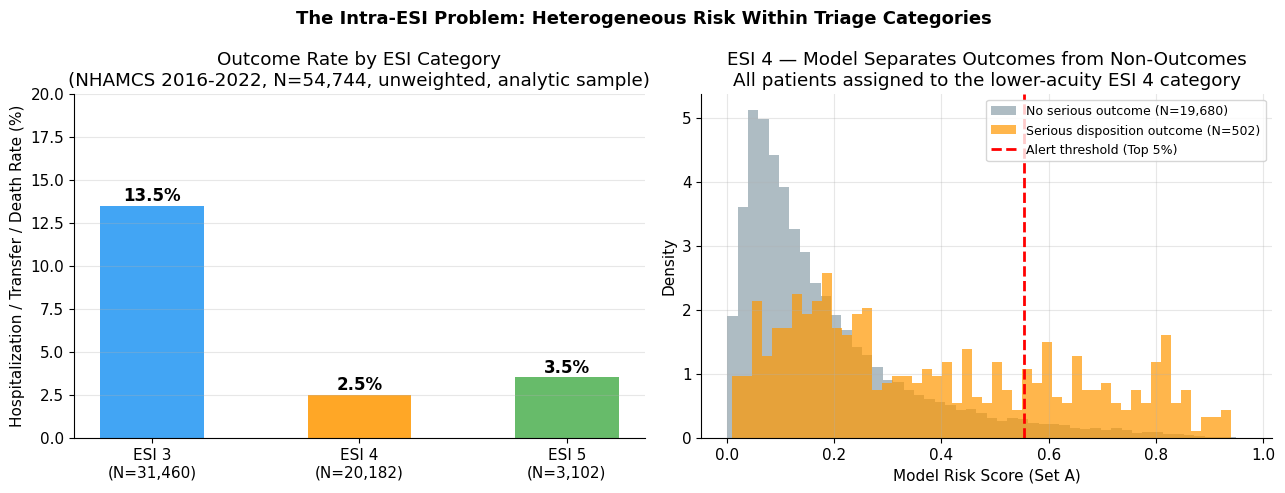

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('The Intra-ESI Problem: Heterogeneous Risk Within Triage Categories',
             fontsize=13, fontweight='bold')

# Panel 1: base rates by ESI — the heterogeneity inside each category
ESI_LABELS = ['ESI 3\n(N=31,460)', 'ESI 4\n(N=20,182)', 'ESI 5\n(N=3,102)']
base_rates = [0.1349, 0.0249, 0.0351]
colors     = ['#2196F3', '#FF9800', '#4CAF50']

ax = axes[0]
bars = ax.bar(ESI_LABELS, [r*100 for r in base_rates], color=colors, width=0.5, alpha=0.85)
for bar, rate in zip(bars, base_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{rate*100:.1f}%', ha='center', fontweight='bold', fontsize=12)
ax.set_ylabel('Hospitalization / Transfer / Death Rate (%)')
ax.set_title('Outcome Rate by ESI Category\n(NHAMCS 2016-2022, N=54,744, unweighted, analytic sample)')
ax.set_ylim([0, 20])
ax.grid(axis='y', alpha=0.3)

# Panel 2: within ESI 4, score distribution for outcomes vs non-outcomes
ax2 = axes[1]
pos4 = df_oof4[df_oof4['outcome'] == 1]['oof_score_A'].values
neg4 = df_oof4[df_oof4['outcome'] == 0]['oof_score_A'].values
ax2.hist(neg4, bins=50, alpha=0.6, color='#78909C', label=f'No serious outcome (N={len(neg4):,})', density=True)
ax2.hist(pos4, bins=50, alpha=0.7, color='#FF9800', label=f'Serious disposition outcome (N={len(pos4):,})', density=True)
cutoff4 = policy['4']['score_cutoff']
ax2.axvline(cutoff4, color='red', ls='--', lw=2, label=f'Alert threshold (Top 5%)')
ax2.set_xlabel('Model Risk Score (Set A)')
ax2.set_ylabel('Density')
ax2.set_title('ESI 4 — Model Separates Outcomes from Non-Outcomes\nAll patients assigned to the lower-acuity ESI 4 category')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(OUT_DIR / '05_esi_scope.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## Section 2 — The Synthetic Data Finding

*This section describes the V1 attempt on the official Kaggle synthetic dataset.
It is the most important methodological contribution of this project.*

### V1: A promising global AUC that hid a fundamental failure

The first version of IntraSight-ESI was built on the official 80,000-patient synthetic dataset.
The global model looked encouraging:

| Metric | Value |
|---|---|
| Global ROC AUC | 0.8255 |
| ESI 4 PR AUC | 0.1266 |
| ESI 4 PR AUC baseline (base rate) | 0.1284 |

But two diagnostic tests revealed the signal was an illusion:

**Shuffle test:** Labels within each ESI group were randomly permuted 500 times.
The AUC of the shuffled model was **0.8267** — *higher* than the real model.
Zero signal remained after shuffling. The model was learning ESI assignment, not intra-ESI risk.

**Targeted biopsy (ESI 4):** PR AUC = 0.1266 vs. baseline 0.1284. Enrichment = **0.94x** — the model
was *worse* than random chance at identifying high-risk ESI 4 patients.

### Why the synthetic data failed — and why this matters

The culprit was the data generation process. In the synthetic dataset, ESI is generated
**almost deterministically** from the same triage variables the model uses as features.
There is no human variability in ESI assignment — no nurse making a judgment call,
no atypical presentation being underweighted. Without that variability, there are no
fine discordances between ESI and clinical outcome to detect.

> **A system designed to find the gap between triage judgment and clinical reality
> cannot be validated on data where that gap was never generated.**

Synthetic data can preserve global distributions. But it loses the fine-grained inter-individual
variability — the subtle mismatches between assigned ESI and actual outcome — that define the
problem this system tries to solve.


### A clinician-led data audit: physiologically impossible records

Beyond the absence of intra-ESI signal, a clinical audit of the synthetic dataset revealed records that cannot exist in a living patient. The strongest finding is unambiguous: **BMI was hard-clamped to the exact interval [10, 65].** The reported BMI never falls below 10.00 or above 65.00, while BMI recomputed from weight and height ranges from 0.52 to 233. A fixed floor and ceiling at round values, with thousands of records sitting exactly on the boundary, is a signature of a programmatic clip, not of biological variation. The accompanying anthropometrics are openly impossible — for example, a 2-year-old recorded at 2 kg and 196 cm, or pediatric heights of 210 cm.

Two further patterns are reported more cautiously, as observations consistent with generation artifacts:

| Audit finding | Magnitude | Why it cannot be physiological |
|---|---|---|
| Pulse pressure ≤ 0 (diastolic ≥ systolic) | 2,105 records (2.6%) | A living patient cannot have diastolic pressure at or above systolic |
| BMI clamped at exactly 10 or 65 | hard min 10.00 / max 65.00 | Round-number boundaries indicate a code-level clip |
| Vitals missing only in ESI 4-5, never ESI 1-3, 0% in deaths | structured, not random | Missingness follows a generation rule, not clinical workflow |

Critically, these impossible records were not assigned at random: the generator attached associations with severity even to physically impossible values (e.g., impossible pulse-pressure records show higher admission and death rates). This is the same phenomenon the shuffle test exposed from a different angle — the synthetic data reproduces *imposed marginal correlations* without preserving the *joint physiology* of a real patient. A model can learn these correlations and appear to work, while the underlying records are clinically incoherent. A domain clinician detects this immediately; an aggregate performance metric does not.

Full audit notebooks (blood pressure / pulse pressure, anthropometry, and missingness) are available in the project repository.


**A distinguishing component of this submission is the explicit synthetic-to-real stress test.** The contrast between synthetic failure
and real-data validation is the original methodological contribution of IntraSight-ESI.


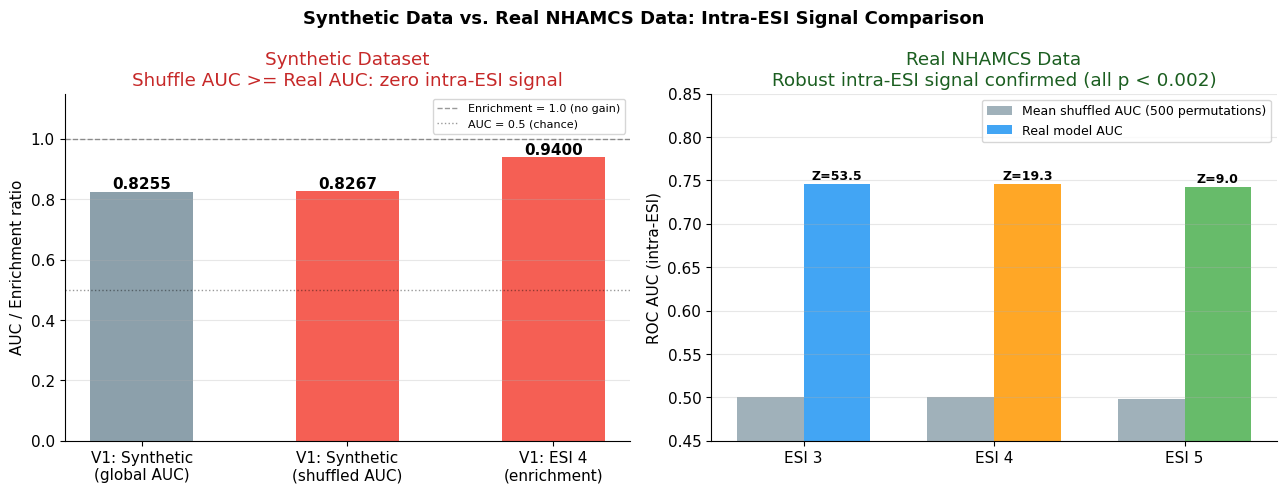

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Synthetic Data vs. Real NHAMCS Data: Intra-ESI Signal Comparison',
             fontsize=13, fontweight='bold')

# Panel 1: Synthetic — no signal
ax = axes[0]
categories = ['V1: Synthetic\n(global AUC)', 'V1: Synthetic\n(shuffled AUC)', 'V1: ESI 4\n(enrichment)']
values     = [0.8255, 0.8267, 0.94]
bar_colors = ['#78909C', '#F44336', '#F44336']
bars = ax.bar(categories, values, color=bar_colors, width=0.5, alpha=0.85)
ax.axhline(1.0, color='black', ls='--', lw=1, alpha=0.4, label='Enrichment = 1.0 (no gain)')
ax.axhline(0.5, color='black', ls=':', lw=1, alpha=0.4, label='AUC = 0.5 (chance)')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylim([0, 1.15])
ax.set_title('Synthetic Dataset\nShuffle AUC >= Real AUC: zero intra-ESI signal', color='#C62828')
ax.set_ylabel('AUC / Enrichment ratio')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# Panel 2: Real NHAMCS — robust signal
ax2 = axes[1]
esi_labels = ['ESI 3', 'ESI 4', 'ESI 5']
real_aucs  = [perm['3']['real_auc'], perm['4']['real_auc'], perm['5']['real_auc']]
shuf_aucs  = [perm['3']['mean_shuffled'], perm['4']['mean_shuffled'], perm['5']['mean_shuffled']]
z_scores   = [perm['3']['z_score'], perm['4']['z_score'], perm['5']['z_score']]
x = np.arange(3)
width = 0.35
ax2.bar(x - width/2, shuf_aucs, width, color='#90A4AE', alpha=0.85, label='Mean shuffled AUC (500 permutations)')
ax2.bar(x + width/2, real_aucs, width, color=['#2196F3','#FF9800','#4CAF50'], alpha=0.85, label='Real model AUC')
for xi, (rauc, z) in enumerate(zip(real_aucs, z_scores)):
    ax2.text(xi + width/2, rauc + 0.005, f'Z={z:.1f}', ha='center', fontsize=9, fontweight='bold')
ax2.set_xticks(x); ax2.set_xticklabels(esi_labels)
ax2.set_ylim([0.45, 0.85])
ax2.set_title('Real NHAMCS Data\nRobust intra-ESI signal confirmed (all p < 0.002)', color='#1B5E20')
ax2.set_ylabel('ROC AUC (intra-ESI)')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(str(OUT_DIR / '05_synthetic_vs_real.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## Section 3 — Validation in Real Data (NHAMCS 2016–2022)

### The dataset

The National Hospital Ambulatory Medical Care Survey (NHAMCS) is a nationally representative sample
of US emergency department visits, published annually by the CDC. We pooled five years (2016–2022,
excluding 2020-21 to avoid COVID-era disruption to ED utilization and triage practices) for a total of **54,744 ESI 3-5 visits**.

**Outcome definition:** `ADMITHOS = 1 OR TRANOTH = 1 OR DIEDED = 1`
(Hospitalization OR transfer to another facility OR death in the ED)

We refer to this composite outcome throughout the notebook as the **serious disposition outcome
(hospitalization, transfer, or ED death)**. This is not "imminent deterioration" — it is
**need for hospital-level care**, an outcome with direct operational implications for bed
management, patient flow, and safety.

### Temporal validation: Leave-One-Year-Out (LOYO)

Each of the 5 years (2016, 2017, 2018, 2019, 2022) serves as the test set once.
Early stopping uses the most recent year within the training set — never the test year.
This eliminates temporal leakage and evaluates robustness across calendar years without using the held-out year for early stopping.

### Three feature sets — three hypotheses

| Set | Features | Hypothesis |
|---|---|---|
| **A — Triage-only** (22 features) | Vitals, demographics, chief complaint (RFV), derived indices | Signal lives in what's available *at triage*, nothing more |
| **B — EHR-at-triage** (35 features) | Set A + 12 comorbidities + comorbidity count | Accessing medical history adds incremental value |
| **C — Leaky control** (36 features) | Set B + NUMMED | Documenting leakage: medications administered *during* the visit inflate AUC |

`NUMMED` was excluded from Sets A and B. It is absent from the landmark Harvard triage ML paper
(Raita et al., *Critical Care* 2019) for the same reason: it is collected during the visit, not at triage.


In [6]:
print("Permutation Test — Intra-ESI Signal (500 shuffles per ESI)")
print("="*65)
print(f"{'ESI':>5} {'N':>7} {'N+':>6} {'Base':>7} {'AUC':>7} {'Shuffled':>9} {'Z-score':>8} {'p-value':>8}")
print("-"*65)

for esi in ['3','4','5']:
    r     = perm[esi]
    base  = policy[esi]['base_rate']
    n_all = {'3': len(df_oof3), '4': len(df_oof4), '5': len(df_oof5)}[esi]
    n_pos = {'3': int(df_oof3['outcome'].sum()), '4': int(df_oof4['outcome'].sum()), '5': int(df_oof5['outcome'].sum())}[esi]
    print(f"  {esi}  {n_all:>7,} {n_pos:>6,} {base:>7.3f} {r['real_auc']:>7.4f} "
          f"{r['mean_shuffled']:>9.4f} {r['z_score']:>8.2f} {'<0.002':>8}")
print("="*65)
print("p-value floor = 1/501 = 0.002 (500 permutations)")
print("All three ESI groups show robust intra-ESI signal absent in synthetic data.")


Permutation Test — Intra-ESI Signal (500 shuffles per ESI)
  ESI       N     N+    Base     AUC  Shuffled  Z-score  p-value
-----------------------------------------------------------------
  3   31,460  4,244   0.135  0.7462    0.5004    53.49   <0.002
  4   20,182    502   0.025  0.7456    0.5003    19.28   <0.002
  5    3,102    109   0.035  0.7424    0.4981     9.01   <0.002
p-value floor = 1/501 = 0.002 (500 permutations)
All three ESI groups show robust intra-ESI signal absent in synthetic data.


In [7]:
print("LOYO Cross-Validation — Set A (Triage-Only Principal Model)")
print("="*70)
print(f"{'ESI':>5} {'N':>7} {'ROC AUC [95% CI]':>22} {'PR AUC [95% CI]':>22} {'Set':>4}")
print("-"*70)

for row in metrics['metrics']:
    if row['set'] != 'A':
        continue
    print(f"  {row['esi']}  {row['n']:>7,}  {row['roc_auc']:.4f} [{row['roc_ci_lo']:.4f}–{row['roc_ci_hi']:.4f}]  "
          f"{row['pr_auc']:.4f} [{row['pr_ci_lo']:.4f}–{row['pr_ci_hi']:.4f}]  {row['set']}")

print()
print("Set B (EHR-at-triage) and Set C (leaky control) comparison:")
print("-"*70)
for row in metrics['metrics']:
    print(f"  ESI{row['esi']}  Set {row['set']}: ROC AUC = {row['roc_auc']:.4f}  PR AUC = {row['pr_auc']:.4f}")
print()
print("Key finding: Set A already achieves the bulk of the discriminative signal.")
print("Set C (NUMMED) inflates ESI 3 AUC by ~3.5 points — the expected leakage signature.")
print("In ESI 4-5 the Set C effect is mixed and noisy, consistent with low positive counts; the leakage signature is clearest where outcome prevalence is highest.")


LOYO Cross-Validation — Set A (Triage-Only Principal Model)
  ESI       N       ROC AUC [95% CI]        PR AUC [95% CI]  Set
----------------------------------------------------------------------
  3   31,460  0.7462 [0.7381–0.7542]  0.3635 [0.3481–0.3790]  A
  4   20,182  0.7456 [0.7224–0.7684]  0.1112 [0.0898–0.1371]  A
  5    3,102  0.7424 [0.6903–0.7905]  0.1538 [0.1071–0.2267]  A

Set B (EHR-at-triage) and Set C (leaky control) comparison:
----------------------------------------------------------------------
  ESI3  Set A: ROC AUC = 0.7462  PR AUC = 0.3635
  ESI3  Set B: ROC AUC = 0.7547  PR AUC = 0.3743
  ESI3  Set C: ROC AUC = 0.7812  PR AUC = 0.4140
  ESI4  Set A: ROC AUC = 0.7456  PR AUC = 0.1112
  ESI4  Set B: ROC AUC = 0.7485  PR AUC = 0.1155
  ESI4  Set C: ROC AUC = 0.7374  PR AUC = 0.1070
  ESI5  Set A: ROC AUC = 0.7424  PR AUC = 0.1538
  ESI5  Set B: ROC AUC = 0.7893  PR AUC = 0.2369
  ESI5  Set C: ROC AUC = 0.7639  PR AUC = 0.1468

Key finding: Set A already achieves th

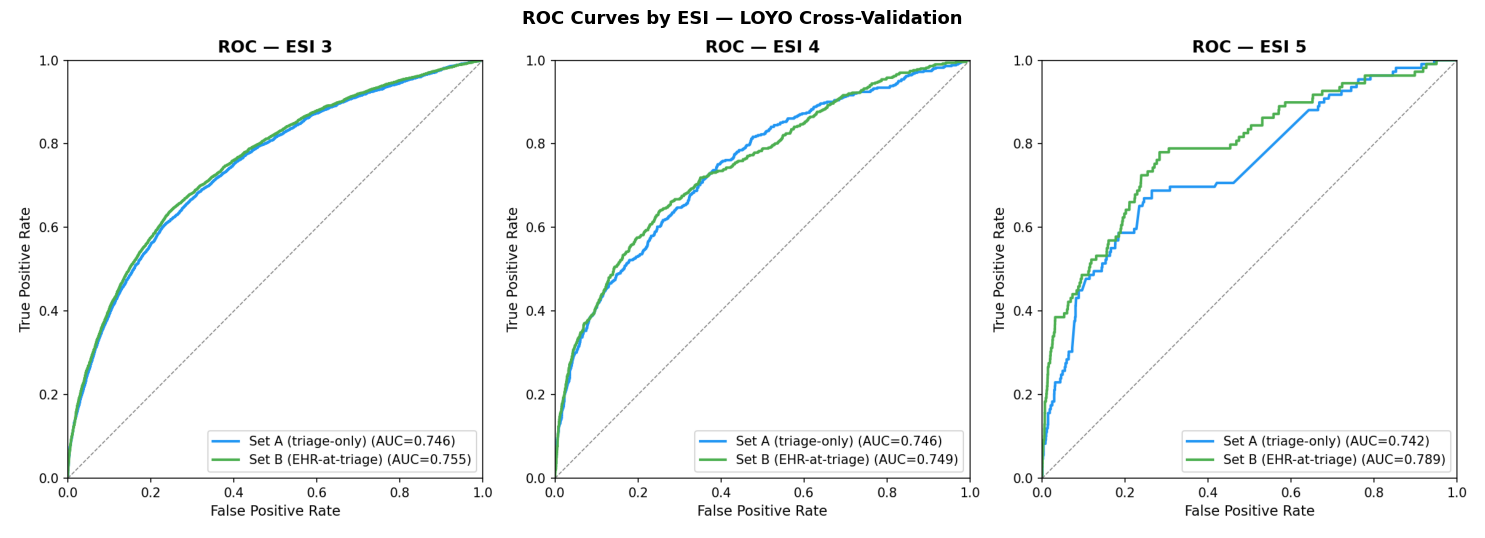

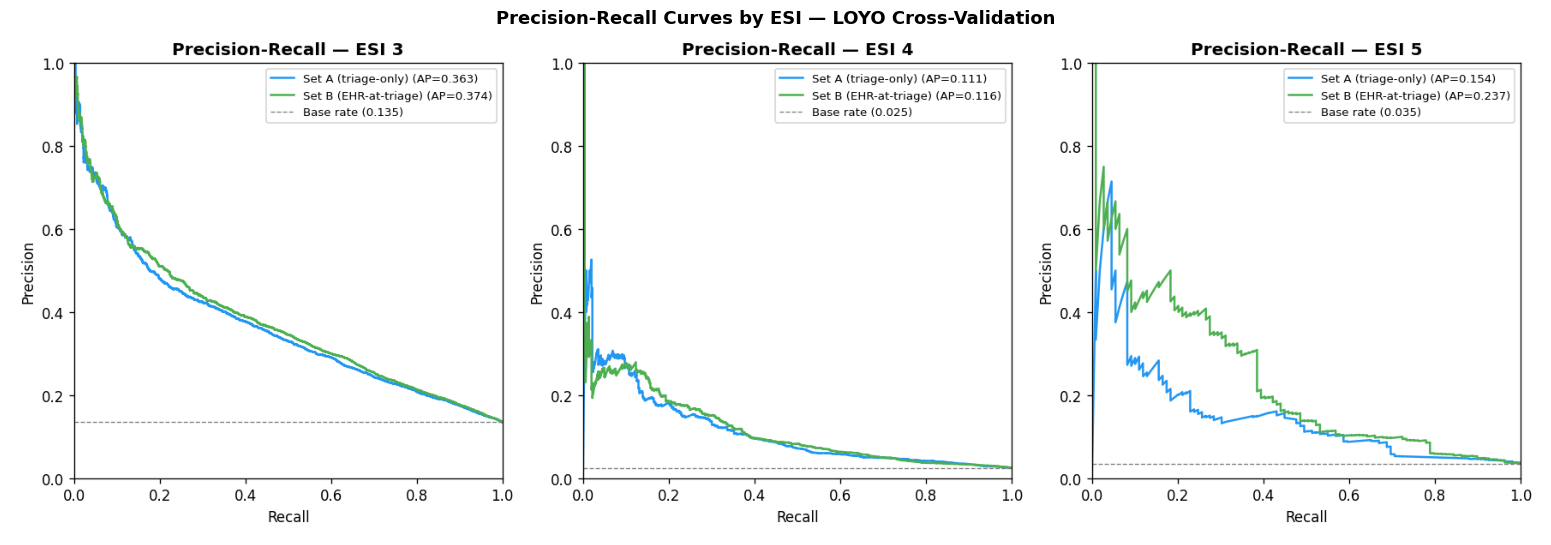

In [8]:
for fname, title, outname in [
    (R02 / '02_roc_curves.png', 'ROC Curves by ESI — LOYO Cross-Validation', '05_roc_curves.png'),
    (R02 / '02_pr_curves.png',  'Precision-Recall Curves by ESI — LOYO Cross-Validation', '05_pr_curves.png'),
]:
    img = mpimg.imread(str(fname))
    fig, ax = plt.subplots(figsize=(16, 5.5))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(str(OUT_DIR / outname), dpi=150, bbox_inches='tight')
    plt.show()


### Linear baseline: does LightGBM add value over logistic regression?

A key methodological question: is the intra-ESI signal genuinely non-linear,
or does the apparent advantage of gradient boosting simply reflect model complexity?

To answer this, we trained a regularized logistic regression (L2 penalty, balanced class weights)
using the same Set A features and the same Leave-One-Year-Out test structure
(each year held out as test once). Within each training set, the regularization
strength C was selected via internal 5-fold stratified cross-validation. Note
that this internal tuning differs from the LightGBM scheme, which reserves the
most recent training year for early stopping; the logistic baseline uses random
stratified folds over all training years. The test fold was never seen during
fitting, imputation, scaling, or C selection in either model.

**Comparison at equal alert burden** (Top 10%/5%/10% per ESI):


Set A — LightGBM vs Logistic Regression L2 (LOYO CV, equal alert burden)
 ESI Model            ROC AUC           [95% CI]   PR AUC  Burden  Enrichment       [95% CI]   Recall
-----------------------------------------------------------------------------------------------
  3  LightGBM          0.7463     [0.7385–0.7541]    0.3636    10.0%       3.1103     [2.99–3.23]    0.3110
  3  LogReg L2         0.7255     [0.7169–0.7339]    0.3206    10.0%       2.8346     [2.70–2.97]    0.2835

  4  LightGBM          0.7455     [0.7222–0.7668]    0.1136     5.0%       5.7717     [4.91–6.63]    0.2888
  4  LogReg L2         0.7426     [0.7193–0.7650]    0.0906     5.0%       5.0553     [4.20–5.87]    0.2530

  5  LightGBM          0.7412     [0.6925–0.7911]    0.1607    10.0%       4.3008     [3.15–5.46]    0.4312
  5  LogReg L2         0.8099     [0.7719–0.8495]    0.1781    10.0%       4.1178     [3.08–5.27]    0.4128

CI: 1000 bootstrap samples on OOF predictions.
Burdens: ESI3=Top10%, ESI4=Top5

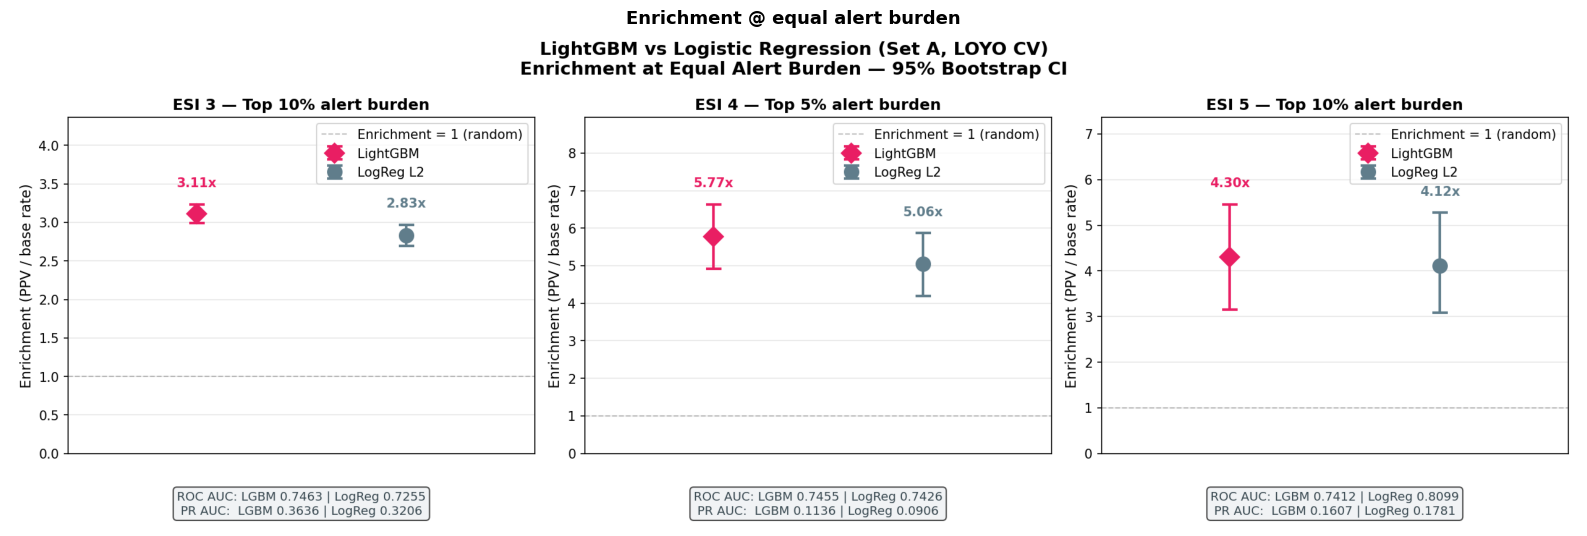

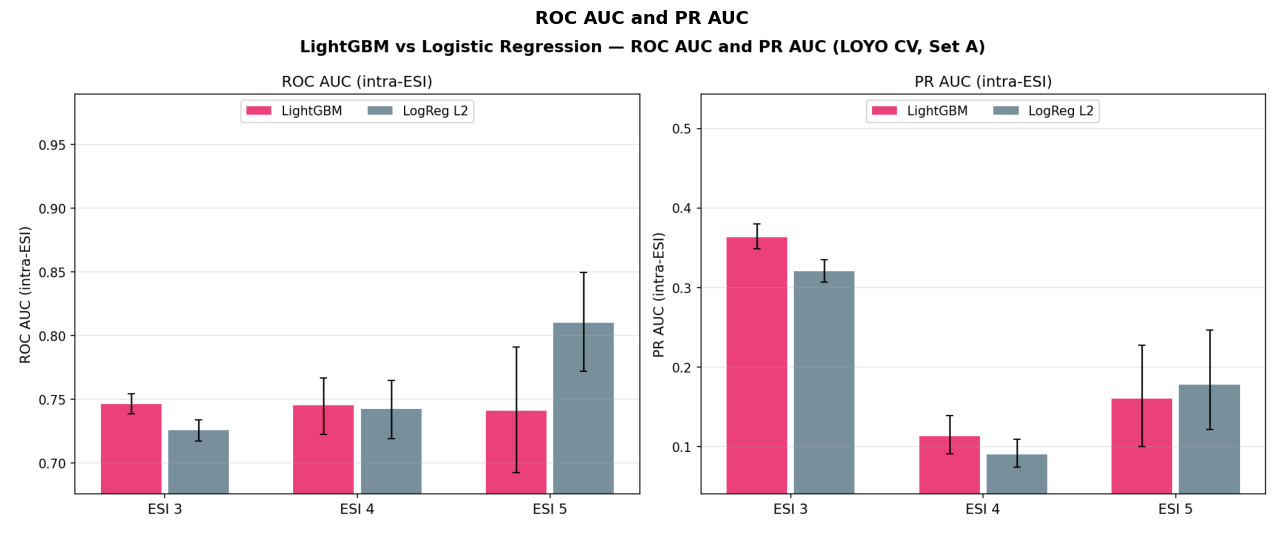

In [9]:
import matplotlib.image as mpimg_lr

# Load logistic regression vs LightGBM comparison
with open(R02b / '02b_logreg_vs_lgbm.json') as f:
    lr_comparison = json.load(f)

df_lr = pd.DataFrame(lr_comparison)

# Print comparison table
print("=" * 95)
print("Set A — LightGBM vs Logistic Regression L2 (LOYO CV, equal alert burden)")
print("=" * 95)
print(f"{'ESI':>4} {'Model':<14} {'ROC AUC':>9} {'[95% CI]':>18} "
      f"{'PR AUC':>8} {'Burden':>7} {'Enrichment':>11} {'[95% CI]':>14} {'Recall':>8}")
print("-" * 95)
for esi in [3, 4, 5]:
    for model_name in ['LightGBM', 'LogReg L2']:
        row = next(r for r in lr_comparison if r['esi']==esi and r['model']==model_name)
        ci_roc = f"[{row['roc_ci_lo']:.4f}–{row['roc_ci_hi']:.4f}]"
        ci_enr = f"[{row['enrichment_ci'][0]:.2f}–{row['enrichment_ci'][1]:.2f}]"
        print(f"  {esi}  {model_name:<14} {row['roc_auc']:>9.4f}  {ci_roc:>18}  "
              f"{row['pr_auc']:>8.4f}  {row['burden_pct']:>6.1f}%  "
              f"{row['enrichment']:>11.4f}  {ci_enr:>14}  {row['recall']:>8.4f}")
    print()
print("=" * 95)
print("CI: 1000 bootstrap samples on OOF predictions.")
print("Burdens: ESI3=Top10%, ESI4=Top5%, ESI5=Top10%  (same as LightGBM policy)")
print()

# Delta summary
print("Delta AUC and enrichment (LightGBM - LogReg):")
for esi in [3, 4, 5]:
    lgbm = next(r for r in lr_comparison if r['esi']==esi and r['model']=='LightGBM')
    lr   = next(r for r in lr_comparison if r['esi']==esi and r['model']=='LogReg L2')
    d_roc = lgbm['roc_auc'] - lr['roc_auc']
    d_enr = lgbm['enrichment'] - lr['enrichment']
    ci_ol = not (lgbm['enrichment_ci'][0] > lr['enrichment_ci'][1] or
                 lr['enrichment_ci'][0]  > lgbm['enrichment_ci'][1])
    flag  = '(CI overlap: not clearly distinct)' if ci_ol else '(non-overlapping CI)'
    print(f"  ESI {esi}: dROC={d_roc:+.4f}  dEnrichment={d_enr:+.3f}x  {flag}")

# Show figure — each composite image gets its own full-width row so the
# panels inside (already multi-panel PNGs) aren't downscaled into illegibility.
for fname, title, fsize, outname in [
    ('02b_logreg_vs_lgbm.png',     'Enrichment @ equal alert burden', (16, 5.5), '05_lr_vs_lgbm_enrichment.png'),
    ('02b_logreg_vs_lgbm_auc.png', 'ROC AUC and PR AUC',               (14, 5.5), '05_lr_vs_lgbm_auc.png'),
]:
    img = mpimg_lr.imread(str(R02b / fname))
    fig, ax = plt.subplots(figsize=fsize)
    ax.imshow(img); ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(str(OUT_DIR / outname), dpi=150, bbox_inches='tight')
    plt.show()


**Interpretation:**

- **ESI 3** (N=31,460, 4,244 outcomes): LightGBM achieves a statistically distinguishable gain
  in ESI 3, the subgroup with the most training signal. We do not attribute this gain to specific
  features: part of it may reflect non-linear structure the linear model cannot capture, and part
  may be an artifact of the numeric encoding of RFV codes, which disadvantages logistic regression.
  The comparison reports aggregate performance only and does not decompose the source of the gap.

- **ESI 4** (N=20,182, 502 outcomes): the models are **practically equivalent**
  (ΔROC = +0.003, enrichment CIs overlap). Even with numeric RFV codes disadvantaging
  logistic regression, the linear model achieves 5.06x enrichment at 5% alert burden.
  The key clinical result — identifying hidden high-risk patients within ESI 4 — is
  robust to model choice.

- **ESI 5** (N=3,102, 109 outcomes): logistic regression actually outperforms on ROC AUC
  (0.810 vs 0.741). With very small sample sizes, gradient boosting's model complexity
  is counterproductive; a heavily regularized linear model (C ≈ 0.008) generalizes better.
  Enrichment is equivalent (CIs overlap).

The regularization strength selected for logistic regression is informative:
ESI 3 (C ≈ 0.46, moderate), ESI 4 and ESI 5 (C ≈ 0.005–0.008, very strong regularization).
In ESI 4, the optimal linear model is effectively a sparse combination of a few dominant
features — confirming that the signal, while real, is concentrated in a small set of
triage variables (chief complaint, mode of arrival, age).

> **Conclusion:** The core contribution of this work is the intra-ESI framing and the
> operational alert policy, not model complexity. The signal is robust to model choice.
> Gradient boosting provides meaningful gains in ESI 3 where training data is richest;
> in ESI 4 — the primary clinical target — both approaches are comparably effective.


---
## Section 4 — The Alert Policy

### Design philosophy: more specific than sensitive

The goal is not to alert on every high-risk patient — it's to identify a **manageable subgroup
with substantially elevated risk** that clinical staff can act on during a busy shift.
A high alert burden causes fatigue and destroys clinical utility.

**Threshold selection principle:** minimum burden achieving recall ≥ 25% with maximum enrichment.
Thresholds were set from cross-validation data *before* seeing the 2015 holdout.
The full threshold sweep (Top 3%, 5%, 10%, 15%, 20%, 25%, 30% by ESI, with PPV, enrichment, recall, and burden at each level) is available in NB03 and informed this selection.
A survey-weighted sensitivity analysis (applying PATWT sampling weights) remains a natural next step for publication-level validation. The logistic regression baseline comparison was conducted as part of this study and is summarized in Section 3.

### Final policy

| ESI | Threshold | Alert burden | PPV | Enrichment | Recall |
|---|---|---|---|---|---|
| **ESI 3** | Top 10% | 10% of ESI 3 patients | 42.0% | 3.11x | 31.1% |
| **ESI 4** | Top 5% | 5% of ESI 4 patients | 14.4% | **5.77x** | 28.9% |
| **ESI 5** | Top 10% | 10% of ESI 5 patients | 15.1% | 4.30x | 43.1% |

> **Note on ESI 5:** simple clinical rules (e.g., age ≥65 AND hypoxemia, 9.49x)
> outperform the model in this group. With only 109 outcomes, ESI 5 is reported
> as exploratory and the model is not recommended as the operative policy here;
> a simple rule is preferable. The model policy is presented for completeness and
> cross-ESI consistency, not as the recommended ESI 5 tool.

**ESI 4 is the star result.** One in seven alerted ESI 4 patients experiences the serious disposition outcome —
5.77 times the base rate of the full ESI 4 category — while only 5% receive alerts.

### Calibration: from ranking tool to probability estimator

Raw LightGBM scores with `scale_pos_weight` are inflated — they rank patients correctly
but their absolute values cannot be communicated as probabilities. After applying
5-fold cross-validated isotonic regression:

Calibration Results — Brier Skill Score
  ESI    Raw Skill  After Iso. Calib.       Interpretation
-------------------------------------------------------
  3       -0.4832            +0.1220  Usable (modest)
  4       -1.8123            +0.0424  Usable (modest)
  5       -0.0218            +0.0494  Usable (modest)

After calibration, all three ESI groups achieve positive Brier skill.
The model is used primarily for within-ESI ranking and percentile-based alerting.
Calibrated probabilities aid interpretability but should not be treated as
definitive individual risk estimates — Brier skill scores remain modest.


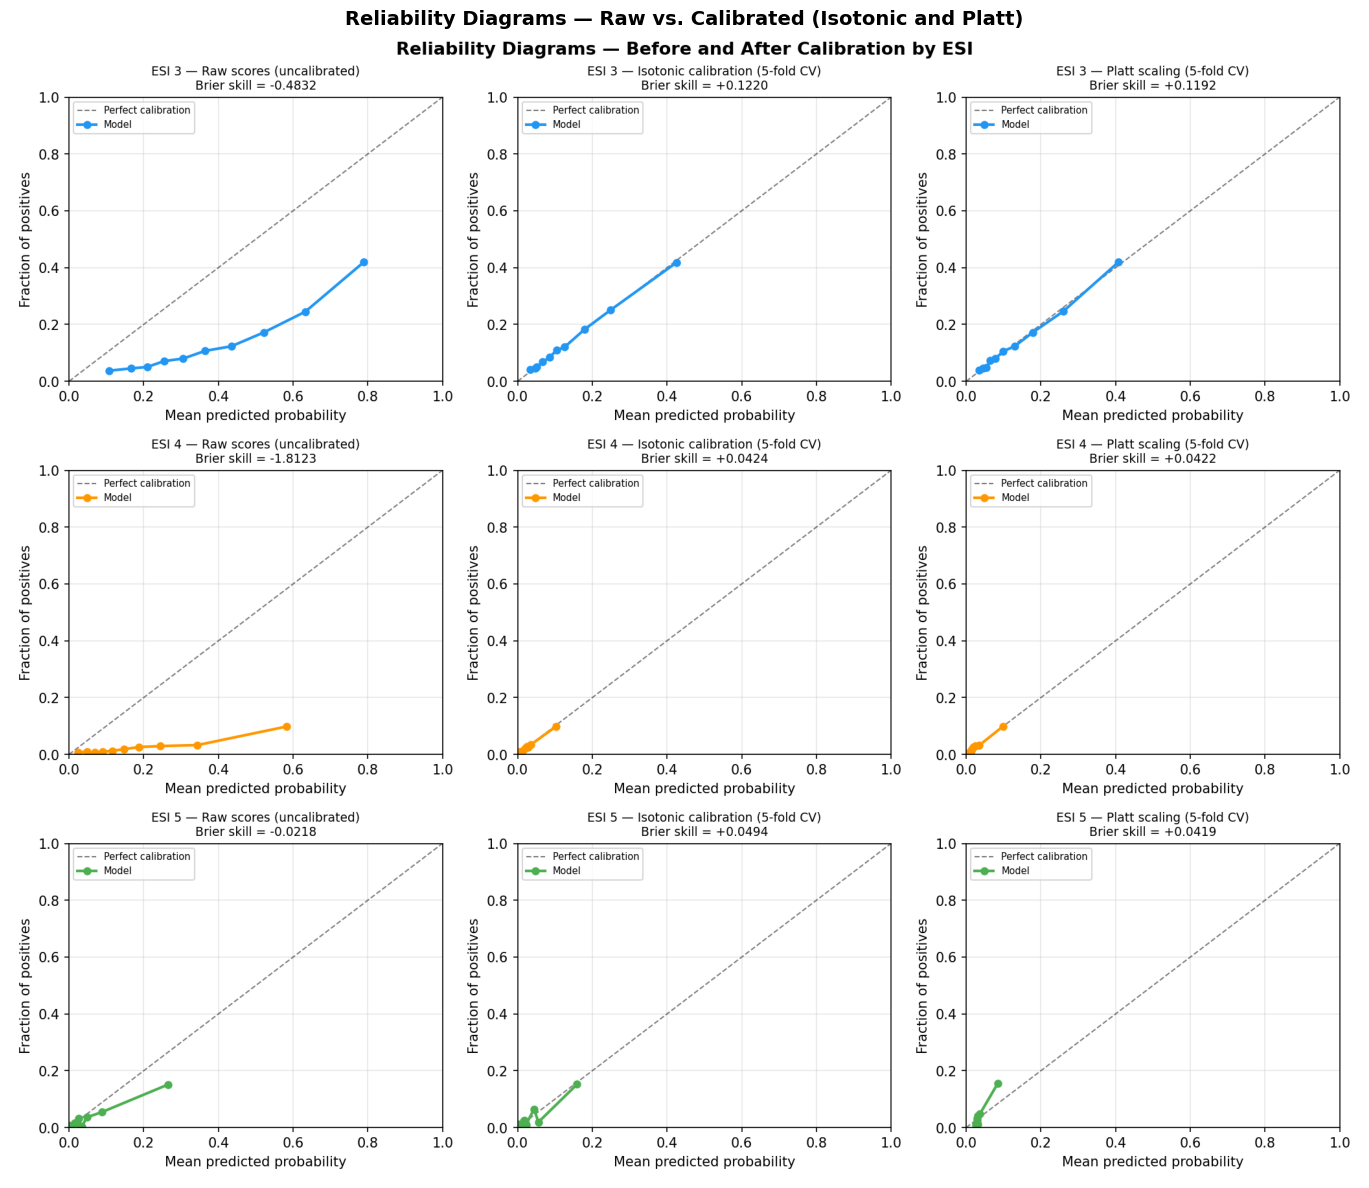

In [10]:
print("Calibration Results — Brier Skill Score")
print("="*55)
print(f"{'ESI':>5} {'Raw Skill':>12} {'After Iso. Calib.':>18} {'Interpretation':>20}")
print("-"*55)

for r in calibration:
    interp = 'Usable (modest)' if r['brier_skill_iso'] > 0.03 else 'Marginal'
    print(f"  {r['esi']}  {r['brier_skill_raw']:>+12.4f} {r['brier_skill_iso']:>+18.4f}  {interp}")
print("="*55)
print()
print("After calibration, all three ESI groups achieve positive Brier skill.")
print("The model is used primarily for within-ESI ranking and percentile-based alerting.")
print("Calibrated probabilities aid interpretability but should not be treated as")
print("definitive individual risk estimates — Brier skill scores remain modest.")

# Show reliability diagram — native figure is a 3x3 grid (14x12in); display
# at matching size so the 9 panels and their legends stay legible.
fig, ax = plt.subplots(1, 1, figsize=(14, 12))
img = mpimg.imread(str(R04 / '04_reliability_diagrams.png'))
ax.imshow(img); ax.axis('off')
ax.set_title('Reliability Diagrams — Raw vs. Calibrated (Isotonic and Platt)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(OUT_DIR / '05_calibration.png'), dpi=150, bbox_inches='tight')
plt.show()


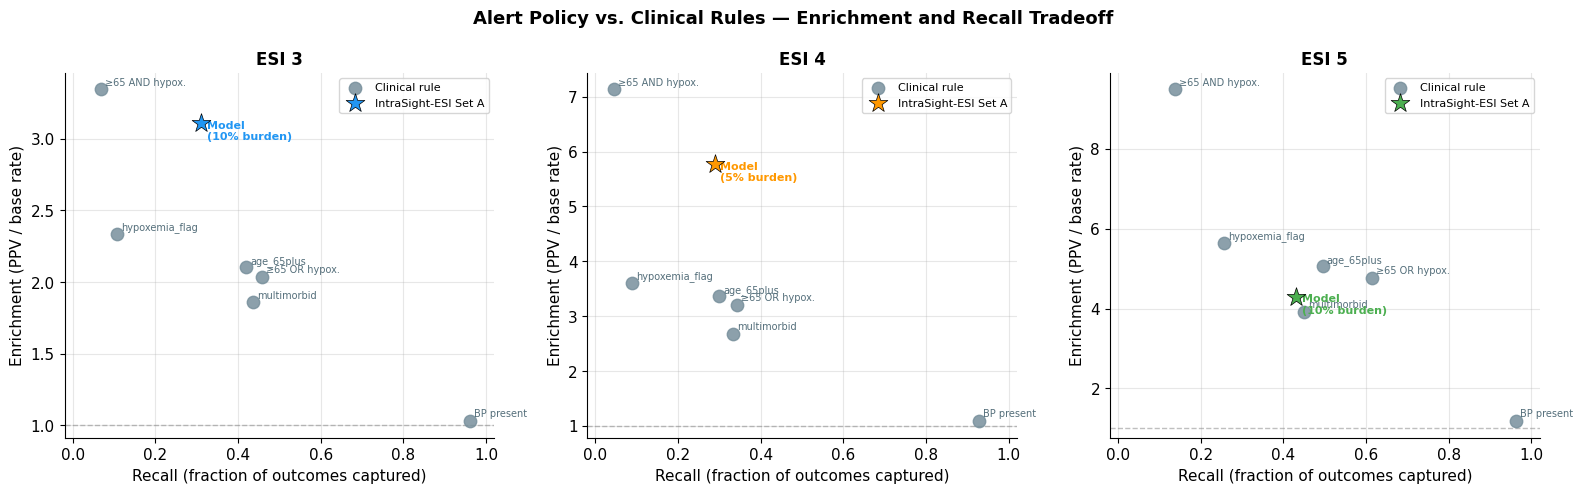

Key insight:
  ESI 3: Model (3.11x, recall=31%) vs best AND-rule (3.35x, recall=6.9%) — model has 4.5x higher recall
  ESI 4: Model (5.77x, recall=29%) vs AND-rule (7.13x, recall=4.4%) — model finds 6x more outcomes
  ESI 5: four simple rules beat the model, including age_65plus AND hypoxemia_flag (9.49x, recall 14%) and hypoxemia_flag alone (5.65x, recall 26%). With only 109 outcomes, the gradient-boosted model does not improve on these rules here — we report this transparently; ESI 5 remains exploratory and simple rules are preferable in this group.

Simple rules are snipers: very high precision, but they miss most outcomes.
In ESI 3 and 4, the model is a radar: broader, higher recall, operationally practical — in ESI 5, the simple rules above win outright.


In [11]:
# Radar vs. sniper: model vs. clinical rules
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Alert Policy vs. Clinical Rules — Enrichment and Recall Tradeoff',
             fontsize=13, fontweight='bold')

ESI_COLORS = {3: '#2196F3', 4: '#FF9800', 5: '#4CAF50'}

for ax, esi in zip(axes, [3, 4, 5]):
    sub   = df_baselines[df_baselines['esi'] == esi].copy()
    model = sub[sub['type'] == 'ML model'].iloc[0]
    rules = sub[sub['type'] == 'clinical rule']

    # Plot rules
    ax.scatter(rules['recall'], rules['enrichment'],
               s=80, color='#78909C', alpha=0.85, zorder=3, label='Clinical rule')
    for _, row in rules.iterrows():
        short_name = row['rule_or_model'].replace('age_65plus AND hypoxemia_flag', '≥65 AND hypox.')
        short_name = short_name.replace('age_65plus OR hypoxemia_flag', '≥65 OR hypox.')
        short_name = short_name.replace('comorbidity_count >= 2', 'multimorbid')
        short_name = short_name.replace('bp_not_missing', 'BP present')
        ax.annotate(short_name, (row['recall'], row['enrichment']),
                    fontsize=7, xytext=(3, 3), textcoords='offset points', color='#546E7A')

    # Plot model
    ax.scatter([model['recall']], [model['enrichment']],
               s=200, color=ESI_COLORS[esi], marker='*', zorder=5,
               edgecolor='black', linewidth=0.5, label='IntraSight-ESI Set A')
    ax.annotate(f"Model\n({model['alert_burden_pct']:.0f}% burden)",
                (model['recall'], model['enrichment']),
                fontsize=8, fontweight='bold', xytext=(4, -12),
                textcoords='offset points', color=ESI_COLORS[esi])

    ax.axhline(1.0, color='gray', ls='--', lw=1, alpha=0.5)
    ax.set_xlabel('Recall (fraction of outcomes captured)')
    ax.set_ylabel('Enrichment (PPV / base rate)')
    ax.set_title(f'ESI {esi}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)
    ax.set_xlim([-0.02, 1.02])

plt.tight_layout()
plt.savefig(str(OUT_DIR / '05_model_vs_baselines.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Key insight:")
print("  ESI 3: Model (3.11x, recall=31%) vs best AND-rule (3.35x, recall=6.9%) — model has 4.5x higher recall")
print("  ESI 4: Model (5.77x, recall=29%) vs AND-rule (7.13x, recall=4.4%) — model finds 6x more outcomes")
print("  ESI 5: four simple rules beat the model, including age_65plus AND hypoxemia_flag (9.49x, recall 14%) and hypoxemia_flag alone (5.65x, recall 26%). With only 109 outcomes, the gradient-boosted model does not improve on these rules here — we report this transparently; ESI 5 remains exploratory and simple rules are preferable in this group.")
print()
print("Simple rules are snipers: very high precision, but they miss most outcomes.")
print("In ESI 3 and 4, the model is a radar: broader, higher recall, operationally practical — in ESI 5, the simple rules above win outright.")


---
## Section 5 — Independent Historical Holdout: NHAMCS 2015

### Why this is the most important validation

> **Terminology note:** 2015 is a historical year *before* the training window (2016–2022). It is an independent historical holdout, not a prospective validation. Prospective validation — applying the frozen model to future data — would require deployment in a live ED and is beyond the scope of this study.

Cross-validation on 2016–2022 tells us the policy works on the *same population it was trained on*.
The 2015 holdout asks a different question: **does the policy hold on an independent historical dataset — one year outside the training window — with score cutoffs fixed before the 2015 data was examined?**

### How 2015 was recovered

NHAMCS 2015 uses a fixed-width ASCII format with different column positions than the 2016–2022 files.
Initial parsing with 2016–2022 column specs produced garbage values for outcome variables
(record width: 2,644 bytes in 2015 vs. 2,456 bytes in 2016–2022).

> NHAMCS 2015 was excluded from all model development due to file layout incompatibility.
> After obtaining the official CDC 2015 codebook, the file was re-parsed with the correct
> column positions. The resulting dataset was **never used in training, cross-validation,
> or threshold selection.** It serves exclusively as an independent temporal holdout.

### Policy application: fixed thresholds, no recalibration

The score cutoffs from NB03 (derived from 2016–2022 CV data) were applied without modification.
This mirrors a fixed-cutoff deployment scenario: score thresholds were determined from 2016–2022 cross-validation and transported to 2015 unchanged. Because these are score-based cutoffs (not percentile-based), alert burden shifts when the score distribution differs across years — a known property of fixed-cutoff policies discussed below.


In [12]:
print("2015 Holdout — Alert Policy Performance with Fixed Thresholds")
print("="*72)
print(f"{'':6} {'ESI 3 CV':>10} {'ESI 3 2015':>11} | {'ESI 4 CV':>10} {'ESI 4 2015':>11} | {'ESI 5 CV':>10} {'ESI 5 2015':>11}")
print("-"*72)

COMPARE = [
    ('Base rate',    'base_rate',        'base_rate'),
    ('Burden (%)',   'alert_burden_pct', 'burden_pct'),
    ('PPV',          'ppv',             'ppv'),
    ('Enrichment',   'enrichment',      'enrichment'),
    ('Recall',       'recall',          'recall'),
]

for label, cv_key, h_key in COMPARE:
    row = f"{label:<14} |"
    for esi in ['3','4','5']:
        cv_v = policy[esi].get(cv_key, float('nan'))
        h_v  = holdout[esi].get(h_key, float('nan'))
        row += f" {cv_v:>10.3f} {h_v:>11.3f} |"
    print(row)
print("="*72)

print()
print("Key findings:")
print("  ESI 3: no policy degradation (3.11x CV vs 3.01x holdout, -3%): well within bootstrap CI")
print("  ESI 4: directionally consistent (5.77x CV vs 7.20x holdout); point estimate favors holdout but 2015 N is smaller — interpret with wider uncertainty")
print("  ESI 5: directionally consistent (4.30x CV vs 7.21x holdout); ESI 5 N=1,041 yields wide CI — ESI 5 results remain exploratory")
print()
print("Burden shift: fixed score cutoffs (not percentile-based) produce different burden ")
print("  on a different year as score distributions shift. A percentile policy would fix ")
print("  alert volume instead. No evidence of policy degradation in any ESI group.")
print()
print("Note: higher holdout enrichment in ESI 4-5 partly reflects lower realized alert")
print("burden under fixed score cutoffs. Interpret as no degradation, not as improvement.")


2015 Holdout — Alert Policy Performance with Fixed Thresholds
         ESI 3 CV  ESI 3 2015 |   ESI 4 CV  ESI 4 2015 |   ESI 5 CV  ESI 5 2015
------------------------------------------------------------------------
Base rate      |      0.135       0.132 |      0.025       0.033 |      0.035       0.020 |
Burden (%)     |     10.000      12.030 |      5.000       3.580 |     10.000       5.280 |
PPV            |      0.420       0.396 |      0.144       0.238 |      0.151       0.145 |
Enrichment     |      3.110       3.010 |      5.772       7.204 |      4.301       7.210 |
Recall         |      0.311       0.362 |      0.289       0.258 |      0.431       0.381 |

Key findings:
  ESI 3: no policy degradation (3.11x CV vs 3.01x holdout, -3%): well within bootstrap CI
  ESI 4: directionally consistent (5.77x CV vs 7.20x holdout); point estimate favors holdout but 2015 N is smaller — interpret with wider uncertainty
  ESI 5: directionally consistent (4.30x CV vs 7.21x holdout); ESI 5 N

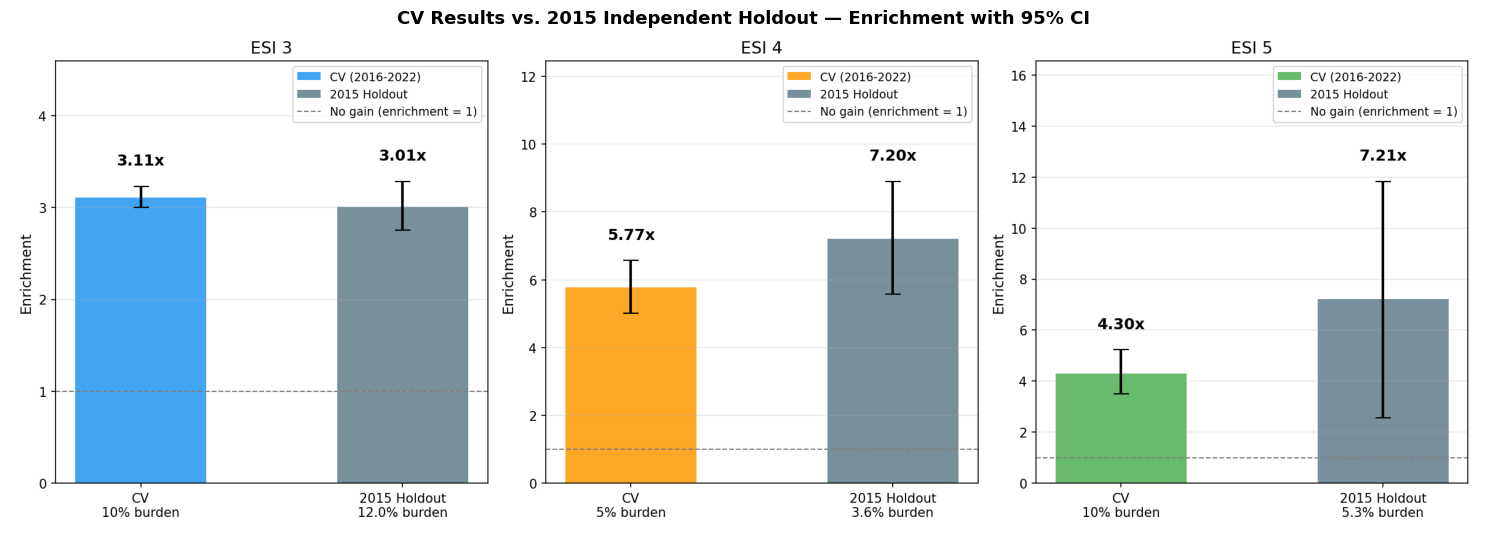

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5.5))
img = mpimg.imread(str(R04 / '04_holdout_vs_cv_plot.png'))
ax.imshow(img); ax.axis('off')
ax.set_title('CV Results vs. 2015 Independent Holdout — Enrichment with 95% CI',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(OUT_DIR / '05_holdout_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## Section 6 — Interpretability and Clinical Insight

### What drives the alerts?

SHAP (SHapley Additive exPlanations) provides per-patient explanations for every alert.
The beeswarm plot below shows the top features for ESI 4, the clinically most important group.

**Consistent findings across ESI groups:**
- **Reason for Visit (RFV1/RFV2):** Chief complaint is the single strongest driver.
  Presentations coded as chest pain, syncope, dyspnea, and weakness in an "ESI 4" patient
  carry substantially elevated within-category risk — these represent residual risk heterogeneity
  that the ESI score, by design, does not capture. This SHAP ranking reflects RFV's contribution
  within the LightGBM model. As noted in the model-comparison section, part of the apparent RFV
  advantage over a linear baseline may stem from how RFV codes are encoded; the SHAP importance
  here describes the model's internal reliance on RFV, not a validated causal clinical effect.
- **Shock index (PULSE/BPSYS):** Even subtle hemodynamic abnormalities within the "normal" range
  for ESI 4-5 significantly elevate predicted risk.
- **Age:** Contributes positively but is not the dominant driver in younger patients — which
  becomes an important finding in the age subgroup analysis (see below).
- **Arrival by ambulance (ARREMS):** Ambulance arrival in an ESI 4-5 patient is a strong signal —
  the mode of transport correlates with functional status in ways that vital signs do not capture.

> **Note:** SHAP values quantify each feature's contribution to the model's predicted score, not causal risk factors. A high SHAP value for age means the model learned that age is predictive in this dataset; it does not establish age as the causal driver of the outcome.


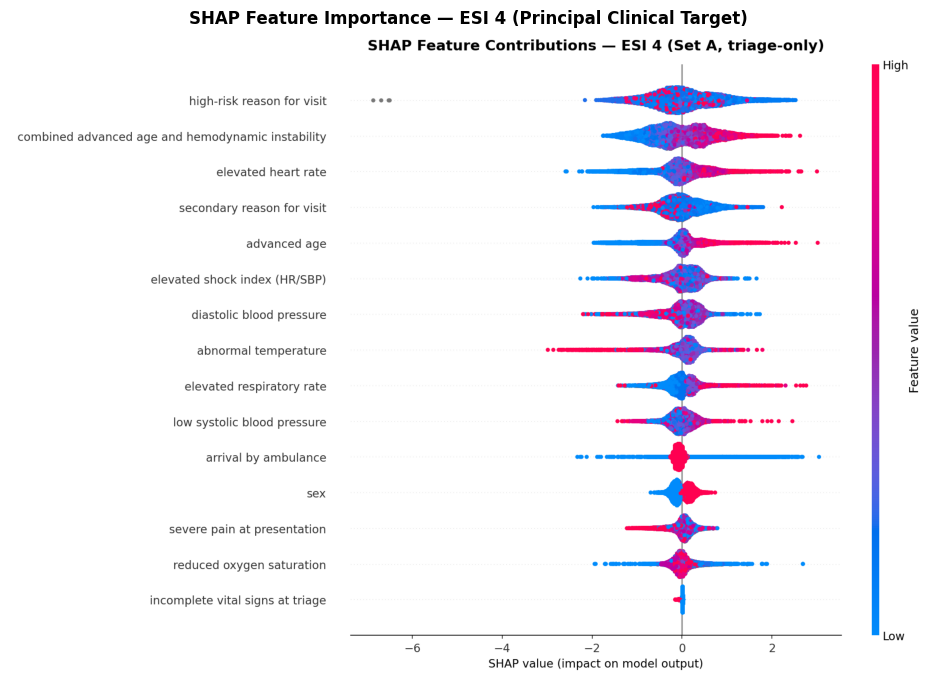

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(12, 7))
img = mpimg.imread(str(R02 / '02_shap_beeswarm_esi4.png'))
ax.imshow(img); ax.axis('off')
ax.set_title('SHAP Feature Importance — ESI 4 (Principal Clinical Target)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(str(OUT_DIR / '05_shap_esi4.png'), dpi=120, bbox_inches='tight')
plt.show()


### Sample alerts from the ESI 4 cohort

The following are real (anonymized) examples from the NHAMCS dataset where the model
generated a prioritization alert. All three patients experienced the serious disposition outcome.


In [15]:
from IPython.display import display, Markdown

# RFV (Reason for Visit) code -> clinical description, decoded directly from
# the official NHAMCS Reason for Visit Classification (RVC), Appendix II,
# docs/doc22-ed-508.pdf (e.g. 1545.1 = "Abdominal pain, cramps, spasms, NOS").
# Code format: 4-digit base code + 1 modifier digit, concatenated without the
# decimal point (1545.1 -> 15451). Only codes appearing in these examples are
# included; an unrecognized code is shown as-is rather than guessed.
RFV_DESCRIPTIONS = {
    11650: 'other psychological/mental health symptoms',
    14150: 'shortness of breath',
    15451: 'abdominal pain',
    17901: 'pain during pregnancy',
}

def rfv_label(code, role):
    if pd.isna(code):
        return role
    code = int(code)
    desc = RFV_DESCRIPTIONS.get(code)
    return f'{role}: {desc}' if desc else f'{role} (RVC code {code})'

FEATURE_LABELS = {
    'AGE':             'advanced age',
    'age_shock_index': 'elevated age-adjusted shock index (combines age and heart rate/blood pressure)',
    'ARREMS':          'arrival by ambulance',
    'RESPR':           'elevated respiratory rate',
}

print("Sample alerts from the ESI 4 cohort\n")
for _, row in df_alerts.head(3).iterrows():
    enr = df_alerts_enriched.loc[df_alerts_enriched['example'] == row['example']].iloc[0]
    spo2_str = f"{row['POPCT']:.0f}%" if not (isinstance(row['POPCT'], float) and np.isnan(row['POPCT'])) else "not recorded"
    resp_str = f"{enr['RESPR']:.0f}" if not (isinstance(enr['RESPR'], float) and np.isnan(enr['RESPR'])) else "not recorded"

    # Percentile within ESI 4 (model estimate, not a certainty) -- truncated
    # rather than rounded so a near-top score never displays as a misleading 100%.
    percentile = (df_oof4['oof_score_A'] <= row['oof_score']).mean() * 100
    percentile = np.floor(percentile * 10) / 10

    # outcome==1 is the composite (hospitalization OR transfer OR ED death) --
    # derive the displayed label from the actual flag, by clinical severity,
    # rather than collapsing every positive case to "HOSPITALIZED".
    if enr['DIEDED'] == 1:
        outcome_label = 'DIED IN ED'
    elif enr['ADMITHOS'] == 1:
        outcome_label = 'HOSPITALIZED (admitted)'
    elif enr['TRANOTH'] == 1:
        outcome_label = 'TRANSFERRED to another facility'
    elif row['outcome'] == 1:
        outcome_label = '[outcome==1 but no ADMITHOS/TRANOTH/DIEDED flag set -- verify]'
    else:
        outcome_label = 'discharged'

    factors = []
    for feat_col in ['top1_feature', 'top2_feature', 'top3_feature']:
        feat = row[feat_col]
        if feat == 'RFV1':
            label = rfv_label(enr['RFV1_code'], 'high-risk reason for visit')
        elif feat == 'RFV2':
            label = rfv_label(enr['RFV2_code'], 'secondary reason for visit')
        else:
            label = FEATURE_LABELS.get(feat, feat.replace('_', ' ').lower())
        factors.append(label)

    # display(Markdown(...)) once per example (rather than one long print() block)
    # so each example is its own output object -- avoids the viewer collapsing a
    # single ~40-line stream block behind an "Output is truncated" banner. Only
    # '>' (blockquote) and '-' (bullet) markdown syntax is used, since both read
    # as normal, clean plain text even if a viewer renders no markdown at all.
    factor_lines = '\n'.join(f'> - {f}' for f in factors)
    md = (
        f"Example {row['example']} — ESI 4 patient, outcome: {outcome_label}\n\n"
        f"Age: {row['AGE']} | SpO2: {spo2_str} | Pulse: {row['PULSE']:.0f} | "
        f"SBP: {row['BPSYS']:.0f} | RR: {resp_str}\n\n"
        f"> [ALERT] PRIORITIZATION ALERT — ESI 4\n"
        f">\n"
        f"> Likely high-risk patient within their ESI 4 category. The model assigns this "
        f"patient an estimated risk higher than {percentile:.1f}% of patients with the same "
        f"triage priority.\n"
        f">\n"
        f"> Contributing factors (in order of model importance):\n"
        f"{factor_lines}\n"
        f">\n"
        f"> Suggested action: reassess earlier than scheduled for this category.\n\n"
        f"---"
    )
    display(Markdown(md))


Sample alerts from the ESI 4 cohort



Example 1 — ESI 4 patient, outcome: HOSPITALIZED (admitted)

Age: 52 | SpO2: 100% | Pulse: 111 | SBP: 185 | RR: 32

> [ALERT] PRIORITIZATION ALERT — ESI 4
>
> Likely high-risk patient within their ESI 4 category. The model assigns this patient an estimated risk higher than 99.0% of patients with the same triage priority.
>
> Contributing factors (in order of model importance):
> - arrival by ambulance
> - elevated respiratory rate
> - high-risk reason for visit: other psychological/mental health symptoms
>
> Suggested action: reassess earlier than scheduled for this category.

---

Example 2 — ESI 4 patient, outcome: TRANSFERRED to another facility

Age: 92 | SpO2: 99% | Pulse: 99 | SBP: 138 | RR: 18

> [ALERT] PRIORITIZATION ALERT — ESI 4
>
> Likely high-risk patient within their ESI 4 category. The model assigns this patient an estimated risk higher than 96.9% of patients with the same triage priority.
>
> Contributing factors (in order of model importance):
> - elevated age-adjusted shock index (combines age and heart rate/blood pressure)
> - advanced age
> - high-risk reason for visit: shortness of breath
>
> Suggested action: reassess earlier than scheduled for this category.

---

Example 3 — ESI 4 patient, outcome: HOSPITALIZED (admitted)

Age: 32 | SpO2: 99% | Pulse: 75 | SBP: 127 | RR: 20

> [ALERT] PRIORITIZATION ALERT — ESI 4
>
> Likely high-risk patient within their ESI 4 category. The model assigns this patient an estimated risk higher than 95.5% of patients with the same triage priority.
>
> Contributing factors (in order of model importance):
> - arrival by ambulance
> - secondary reason for visit: abdominal pain
> - high-risk reason for visit: pain during pregnancy
>
> Suggested action: reassess earlier than scheduled for this category.

---

### A refined finding on age

**Pre-declared hypothesis (NB00):** The gap between ESI assigned and actual clinical risk
is more pronounced in patients ≥65 — frailty, atypical presentation, reduced reserve.

**What the data showed:**


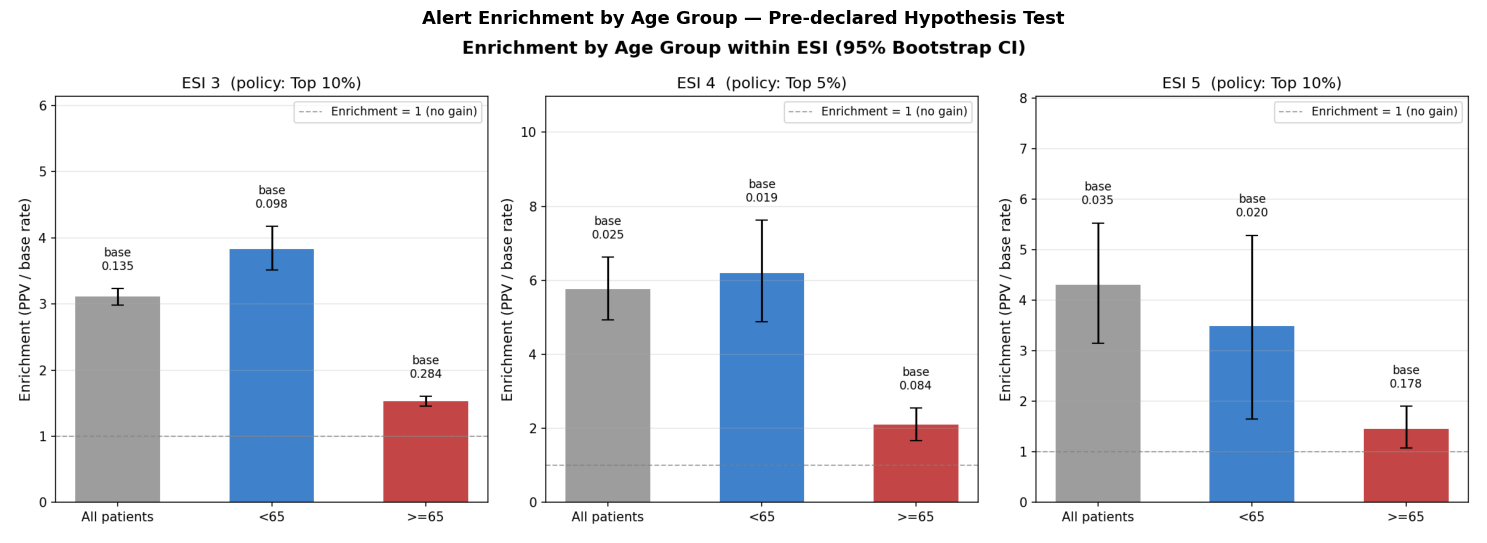

Age >=65 subgroup findings:
  ESI 3:
    <65 : base rate 0.098 | enrichment 3.83x | recall 0.118
    >=65: base rate 0.284 | enrichment 1.53x | recall 0.579
  ESI 4:
    <65 : base rate 0.019 | enrichment 6.20x | recall 0.190
    >=65: base rate 0.084 | enrichment 2.10x | recall 0.520
  ESI 5:
    <65 : base rate 0.020 | enrichment 3.49x | recall 0.218
    >=65: base rate 0.178 | enrichment 1.45x | recall 0.648


In [16]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5.5))
img = mpimg.imread(str(R04 / '04_subgroup_age65_plot.png'))
ax.imshow(img); ax.axis('off')
ax.set_title('Alert Enrichment by Age Group — Pre-declared Hypothesis Test',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(OUT_DIR / '05_age_subgroup.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Age >=65 subgroup findings:")
for esi in [3, 4, 5]:
    sub = df_age65[df_age65['esi'] == esi]
    lt  = sub[sub['age_group'] == '<65'].iloc[0]
    ge  = sub[sub['age_group'] == '>=65'].iloc[0]
    print(f"  ESI {esi}:")
    print(f"    <65 : base rate {lt['base_rate']:.3f} | enrichment {lt['enrichment']:.2f}x | recall {lt['recall']:.3f}")
    print(f"    >=65: base rate {ge['base_rate']:.3f} | enrichment {ge['enrichment']:.2f}x | recall {ge['recall']:.3f}")


### Interpreting the age finding: a refinement, not a failure

The pre-registered hypothesis — that model enrichment would be greater in
patients ≥65 — was not confirmed: enrichment was age-agnostic or lower in the
older group. We report this plainly before offering the following refinement.

The enrichment *ratio* (PPV / base rate) is lower for ≥65 patients. This is expected:
their base rates are already 3–5× higher than younger patients within the same ESI category.
**The ESI system itself partly recognizes their elevated risk.**

But two findings remain clinically important:

1. **The model captures a high fraction of ≥65 outcomes** (recall 52–65% in ESI 4-5).
   These patients are not missed — the system flags them at high rates.

2. **The model adds more incremental value in <65 patients.** A 6.20x enrichment for
   ESI 4 patients under 65 means the model is surfacing risk that age alone would not flag —
   the hidden patient with a dangerous presentation but unremarkable demographics.

**Clinical interpretation:** In an elderly patient, the ESI itself already signals "watch this person."
In a 45-year-old with normal vitals and an ESI 4 assignment, the model's 6.20x enrichment
represents genuine value-add: risk the system would otherwise miss entirely.

This is a more precise and clinically useful insight than confirming the original hypothesis would have been.


---
## Section 7 — Fairness Audit

RACERETH and PAYTYPER were never used as predictors in any model. SEX is a
clinically legitimate predictor and is included in Set A; it is audited here
for equity of alert distribution, not excluded from modeling.

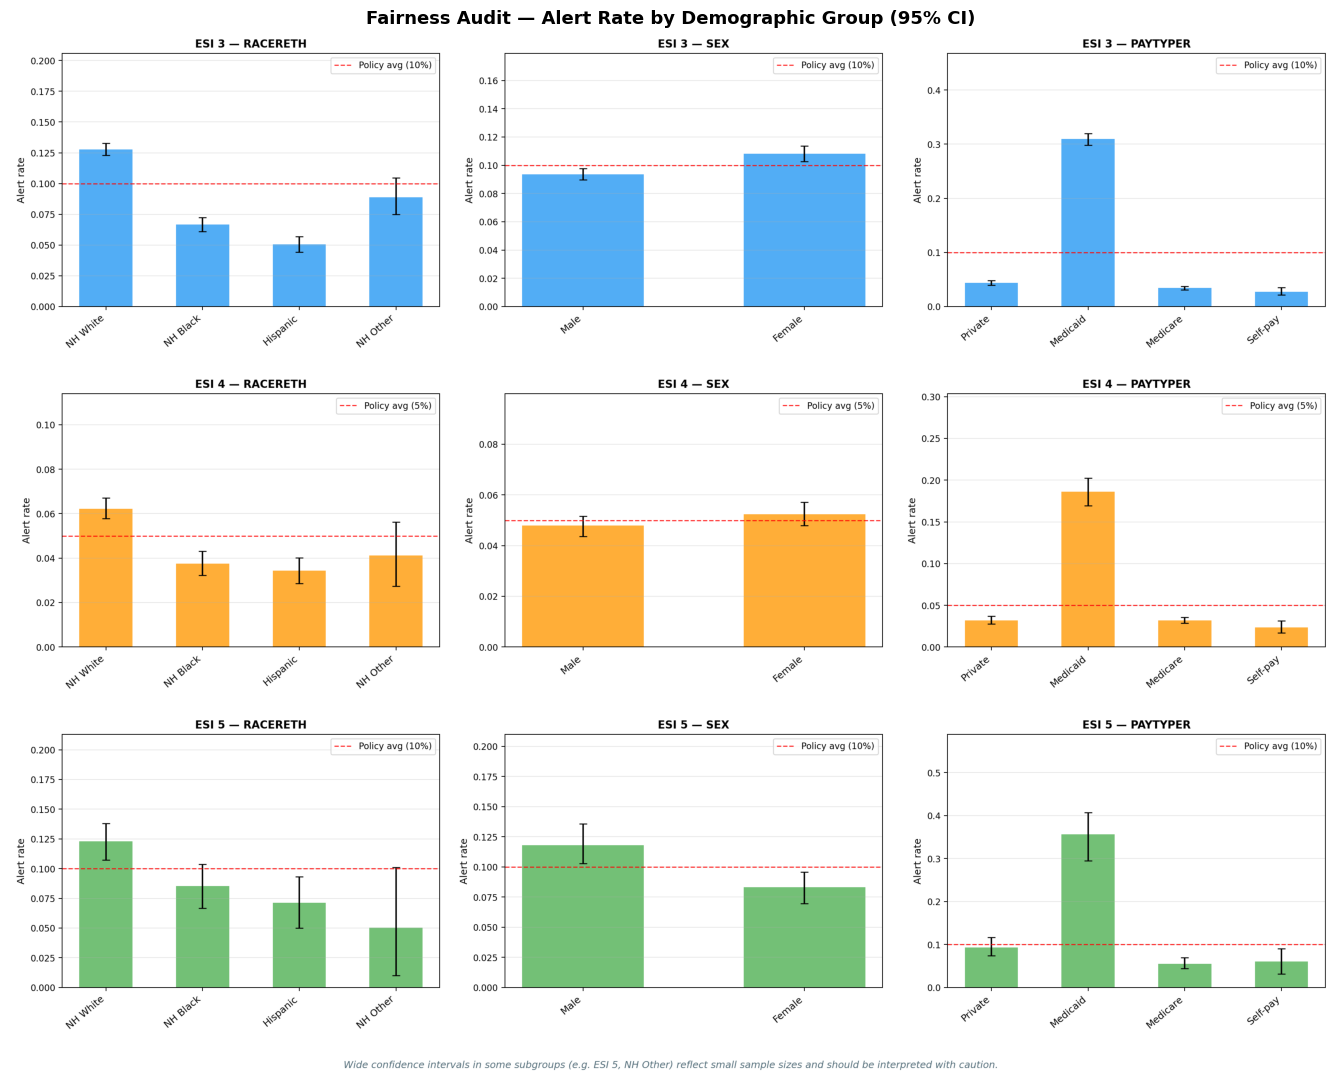

ESI 4 — RACERETH alert rate and PPV:
      NH White: N=10,609 | base=0.029 | alert=0.062 | PPV=0.132
      NH Black: N=5,198 | base=0.018 | alert=0.037 | PPV=0.185
      Hispanic: N=3,645 | base=0.023 | alert=0.034 | PPV=0.144
      NH Other: N=  730 | base=0.014 | alert=0.041 | PPV=0.133


In [17]:
fig, ax = plt.subplots(1, 1, figsize=(15, 11))
img = mpimg.imread(str(R04 / '04_fairness_by_group.png'))
ax.imshow(img); ax.axis('off')
ax.set_title('Fairness Audit — Alert Rate by Demographic Group (95% CI)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(OUT_DIR / '05_fairness.png'), dpi=150, bbox_inches='tight')
plt.show()

print("ESI 4 — RACERETH alert rate and PPV:")
sub_f = df_fairness[(df_fairness['esi']==4) & (df_fairness['demo_var']=='RACERETH')]
for _, row in sub_f.iterrows():
    norm_rate = row['alert_rate'] / policy['4']['alert_burden_pct'] * 100
    print(f"  {row['group']:>12}: N={row['n']:>5,} | base={row['base_rate']:.3f} | "
          f"alert={row['alert_rate']:.3f} | PPV={row['ppv']:.3f}")


### Fairness findings and their dual interpretation

**Observed pattern (ESI 4):**
- Non-Hispanic White patients receive alerts at 6.2% vs. NH Black at 3.7% and Hispanic at 3.4%
- However, when NH Black patients *are* alerted, their PPV is **higher** (0.185 vs. 0.132)

**Two equally valid readings:**

1. **Under-triage signal:** Alert-rate differences may reflect differences in measured feature distributions, baseline risk, documentation patterns, access patterns, coding practices, or model behavior.

2. **Model bias:** The model may be under-weighting risk indicators for NH Black patients,
   particularly if training data underrepresents the clinical complexity of those visits.
   The higher PPV when alerts *do* fire suggests the model is calibrated when it alerts —
   but it may not alert frequently enough.

**What the data cannot determine:** Without causal identification (randomized triage,
prospective validation), we cannot distinguish between these interpretations.
Alert-rate differences may reflect baseline risk, feature distributions, access
patterns, coding practices, or model behavior -- or any combination thereof.

> We report these findings transparently. **RACERETH and PAYTYPER were excluded
> from all predictive models** in this study. Any deployment of this system should
> include prospective auditing of alert rates by demographic group before and after
> go-live, and outcome tracking by group over time.


---
## Section 8 — Limitations

**1. NHAMCS is a survey, not a hospital log.**
NHAMCS uses complex sampling weights (PATWT) for national estimates. This analysis treats
all visits equally (unweighted) — a valid choice for model development, but results should not
be extrapolated as nationally representative without applying survey weights.

**2. No prospective validation.**
All results come from retrospective cross-validation and a historical holdout. Prospective
deployment in a live ED would require additional validation, particularly for alert burden
calibration under real workflow conditions.

**3. Chief complaint is structured (RFV), not free text.**
RFV codes are a structured approximation of chief complaint. Free-text NLP on actual
triage notes could substantially improve signal, particularly for atypical presentations.

**4. ESI 5 results are exploratory.**
N=3,102 (holdout N=1,041) produces wide confidence intervals. ESI 5 findings are
directionally consistent but should not be used operationally without larger samples.

**5. Fairness requires causal investigation.**
Observed alert rate disparities by race/ethnicity cannot be attributed to model bias or
real clinical differences without a causal framework. Prospective audit is required.

**6. ESI variability between hospitals is not controlled.**
NHAMCS aggregates visits across hundreds of hospitals with varying ESI assignment consistency.
A single-hospital deployment would benefit from institution-specific recalibration.

**7. Temporal heterogeneity and the COVID gap.**
Pooling 2016–2019 with 2022 (2020–21 excluded) spans a structural break in ED case mix,
admission thresholds, and transfer patterns. LOYO mixes these regimes; single-period
deployment would require re-validation.

**8. Counterintuitive ESI 5 base rate.**
The ESI 5 outcome rate (3.5%) exceeds ESI 4 (2.5%) in this unweighted analytic sample.
We report this pattern without attributing a cause; the present data do not allow us
to determine its origin. It is nonetheless consistent with the central thesis that ESI
category does not fully determine clinical destination.

---
## Section 9 — Methodology Note

This project was developed by an emergency physician with intermediate programming skills,
using AI-assisted development (Claude, Anthropic) for code generation, pipeline construction,
and methodological review. All clinical decisions — outcome definition, variable selection,
feature engineering rationale, scope justification (ESI 1-2 exclusion), threshold philosophy,
subgroup hypotheses, and clinical interpretations — were made by the author independently.
The AI system had no access to clinical judgment and was used exclusively as a coding and
statistical implementation tool.

The protocol, hypotheses, and subgroup definitions were written before final model training, alert policy selection, and subgroup interpretation (NB00), following pre-registration principles.


---
## Section 10 — Conclusion

This project started with a failure.

The first model, built on the official Kaggle synthetic dataset, achieved AUC 0.8255 —
and then fell apart under a simple shuffle test. The signal wasn't intra-ESI risk.
It was ESI itself, encoded in the features. The synthetic data had no discordances to find.

That failure led to the right question: what does the *real* data look like?

On five years of real US emergency visits, the signal is robust and replicable within this
retrospective NHAMCS sample:
- Permutation tests with Z-scores of 53, 19, and 9 confirm genuine intra-ESI predictability
- The triage-only model (Set A) achieves most of the discriminative signal — no leakage required
- The alert policy generalizes to an independent 2015 holdout with enrichment of 3.0x / 7.2x / 7.2x (the higher ESI 4-5 holdout values partly reflect lower realized alert burden under fixed cutoffs, not a performance gain; see Section 5) (ESI 5 excepted — see Section 4: simple rules outperform the model there and ESI 5 remains exploratory)

The ESI system works. It correctly identifies patients who need immediate attention.
What it was never designed to do — and what no triage tool should be expected to do alone —
is identify which waiting patients have elevated downstream serious disposition risk within the same category.

**The star result:** In ESI 4, the top 5% of patients by model score have 14% PPV —
5.77 times the base rate. One in seven alerted patients experiences the serious disposition outcome.
The alert is not a rule-out tool. Non-alerted patients still require standard clinical reassessment per their ESI category — the system adds a prioritization layer within the existing care pathway, it does not substitute for it.

**The age finding:** Older patients benefit from the system's recall (52–65% captured).
But the model's largest incremental value is in patients under 65 with ESI 4 or 5,
where age provides no obvious clinical cue and risk is genuinely hidden.

**The broader lesson:** A model can look excellent globally and fail precisely where it matters.
The gap between a synthetic benchmark and real-world clinical heterogeneity is not a data quality problem —
it's a fundamental difference in what the data was generated to represent.

IntraSight-ESI adds a second layer of attention where it is most needed:
**the patient who is invisible in the waiting room.**


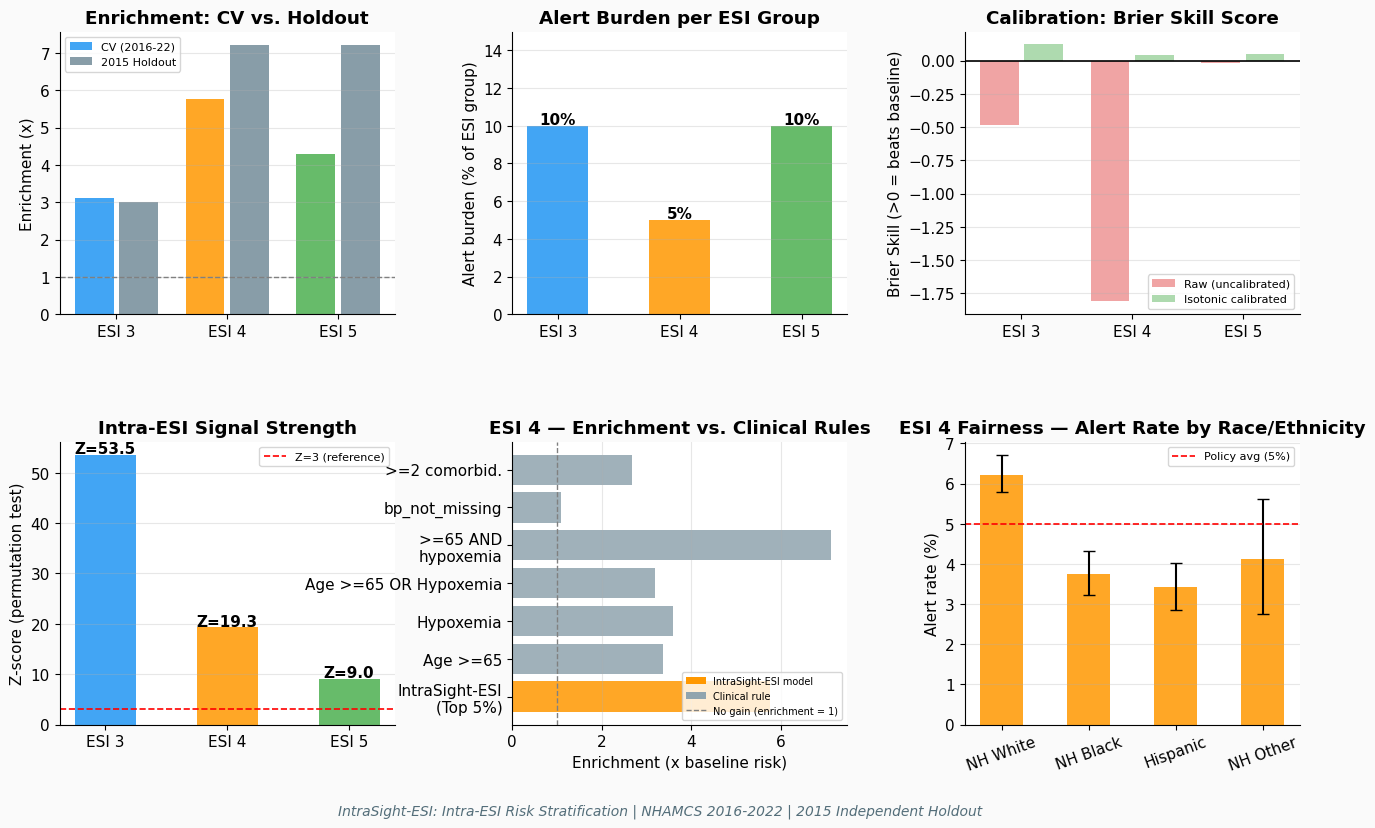

Cover image saved: reports/05_summary_dashboard.png


In [18]:
# Summary figure — key metrics at a glance
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

fig = plt.figure(figsize=(16, 9))
fig.patch.set_facecolor('#FAFAFA')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

ESI_COLORS = {3: '#2196F3', 4: '#FF9800', 5: '#4CAF50'}
ESI_LABELS = {3: 'ESI 3', 4: 'ESI 4', 5: 'ESI 5'}

# Panel 1: Enrichment CV vs Holdout
ax1 = fig.add_subplot(gs[0, 0])
x = np.arange(3)
cv_enrs  = [policy[str(e)]['enrichment']   for e in [3,4,5]]
h_enrs   = [holdout[str(e)]['enrichment']  for e in [3,4,5]]
ax1.bar(x - 0.2, cv_enrs,  0.35, color=[ESI_COLORS[e] for e in [3,4,5]], alpha=0.85, label='CV (2016-22)')
ax1.bar(x + 0.2, h_enrs,   0.35, color='#607D8B', alpha=0.75, label='2015 Holdout')
ax1.axhline(1, color='gray', ls='--', lw=1)
ax1.set_xticks(x); ax1.set_xticklabels(['ESI 3','ESI 4','ESI 5'])
ax1.set_title('Enrichment: CV vs. Holdout', fontweight='bold')
ax1.set_ylabel('Enrichment (x)'); ax1.legend(fontsize=8); ax1.grid(axis='y', alpha=0.3)

# Panel 2: Alert burden
ax2 = fig.add_subplot(gs[0, 1])
burdens = [policy[str(e)]['threshold_pct'] for e in [3,4,5]]
ax2.bar(['ESI 3','ESI 4','ESI 5'], burdens,
        color=[ESI_COLORS[e] for e in [3,4,5]], alpha=0.85, width=0.5)
for xi, b in enumerate(burdens):
    ax2.text(xi, b+0.1, f'{b:.0f}%', ha='center', fontweight='bold')
ax2.set_ylabel('Alert burden (% of ESI group)'); ax2.set_ylim([0,15])
ax2.set_title('Alert Burden per ESI Group', fontweight='bold'); ax2.grid(axis='y', alpha=0.3)

# Panel 3: Brier skill before / after calibration
ax3 = fig.add_subplot(gs[0, 2])
raw_skills = [r['brier_skill_raw'] for r in calibration]
iso_skills = [r['brier_skill_iso'] for r in calibration]
x = np.arange(3)
ax3.bar(x - 0.2, raw_skills, 0.35, color='#EF9A9A', alpha=0.9, label='Raw (uncalibrated)')
ax3.bar(x + 0.2, iso_skills, 0.35, color='#A5D6A7', alpha=0.9, label='Isotonic calibrated')
ax3.axhline(0, color='black', lw=1.2)
ax3.set_xticks(x); ax3.set_xticklabels(['ESI 3','ESI 4','ESI 5'])
ax3.set_title('Calibration: Brier Skill Score', fontweight='bold')
ax3.set_ylabel('Brier Skill (>0 = beats baseline)'); ax3.legend(fontsize=8); ax3.grid(axis='y', alpha=0.3)

# Panel 4: Synthetic vs real Z-scores
ax4 = fig.add_subplot(gs[1, 0])
z_scores = [perm[str(e)]['z_score'] for e in [3,4,5]]
ax4.bar(['ESI 3','ESI 4','ESI 5'], z_scores,
        color=[ESI_COLORS[e] for e in [3,4,5]], alpha=0.85, width=0.5)
ax4.axhline(3.0, color='red', ls='--', lw=1.2, label='Z=3 (reference)')
for xi, z in enumerate(z_scores):
    ax4.text(xi, z+0.3, f'Z={z:.1f}', ha='center', fontweight='bold')
ax4.set_ylabel('Z-score (permutation test)'); ax4.set_title('Intra-ESI Signal Strength', fontweight='bold')
ax4.legend(fontsize=8); ax4.grid(axis='y', alpha=0.3)

# Panel 5: PPV for model vs key baselines in ESI 4
ax5 = fig.add_subplot(gs[1, 1])
esi4_base = df_baselines[df_baselines['esi']==4].copy()
names  = esi4_base['rule_or_model'].str.replace('Model Set A (Top 5%)', 'IntraSight-ESI\n(Top 5%)')
names  = names.str.replace('age_65plus AND hypoxemia_flag', '>=65 AND\nhypoxemia')
names  = names.str.replace('age_65plus', 'Age >=65')
names  = names.str.replace('comorbidity_count >= 2', '>=2 comorbid.')
names  = names.str.replace('hypoxemia_flag', 'Hypoxemia')
bar_c  = ['#FF9800' if 'IntraSight-ESI' in str(n) else '#90A4AE' for n in names]
ax5.barh(names, esi4_base['enrichment'], color=bar_c, alpha=0.85)
ax5.axvline(1, color='gray', ls='--', lw=1)
ax5.legend(handles=[Patch(facecolor='#FF9800', label='IntraSight-ESI model'),
                     Patch(facecolor='#90A4AE', label='Clinical rule'),
                     Line2D([0], [0], color='gray', ls='--', lw=1, label='No gain (enrichment = 1)')],
           fontsize=7, loc='lower right')
ax5.set_title('ESI 4 — Enrichment vs. Clinical Rules', fontweight='bold')
ax5.set_xlabel('Enrichment (x baseline risk)'); ax5.grid(axis='x', alpha=0.3)

# Panel 6: Fairness alert rates ESI 4 by race
ax6 = fig.add_subplot(gs[1, 2])
fair_r = df_fairness[(df_fairness['esi']==4) & (df_fairness['demo_var']=='RACERETH')]
ax6.bar(fair_r['group'], fair_r['alert_rate']*100,
        color=ESI_COLORS[4], alpha=0.85, width=0.5)
ax6.errorbar(range(len(fair_r)), fair_r['alert_rate']*100,
             yerr=[(fair_r['alert_rate'] - fair_r['alert_ci_lo'])*100,
                   (fair_r['alert_ci_hi'] - fair_r['alert_rate'])*100],
             fmt='none', color='black', capsize=4, lw=1.5)
ax6.axhline(policy['4']['threshold_pct'], color='red', ls='--', lw=1.2, label=f'Policy avg (5%)')
ax6.set_ylabel('Alert rate (%)'); ax6.set_title('ESI 4 Fairness — Alert Rate by Race/Ethnicity', fontweight='bold')
ax6.legend(fontsize=8); ax6.grid(axis='y', alpha=0.3)
ax6.tick_params(axis='x', rotation=20)

fig.text(0.5, 0.01,
         'IntraSight-ESI: Intra-ESI Risk Stratification | NHAMCS 2016-2022 | 2015 Independent Holdout',
         ha='center', fontsize=10, color='#546E7A', style='italic')

plt.savefig(str(OUT_DIR / '05_summary_dashboard.png'), dpi=150, bbox_inches='tight',
            facecolor='#FAFAFA')
plt.show()
print("Cover image saved: reports/05_summary_dashboard.png")
